In [7]:
import itertools
import math
import matplotlib.pyplot
import numpy as np
import pandas as pd
import sys

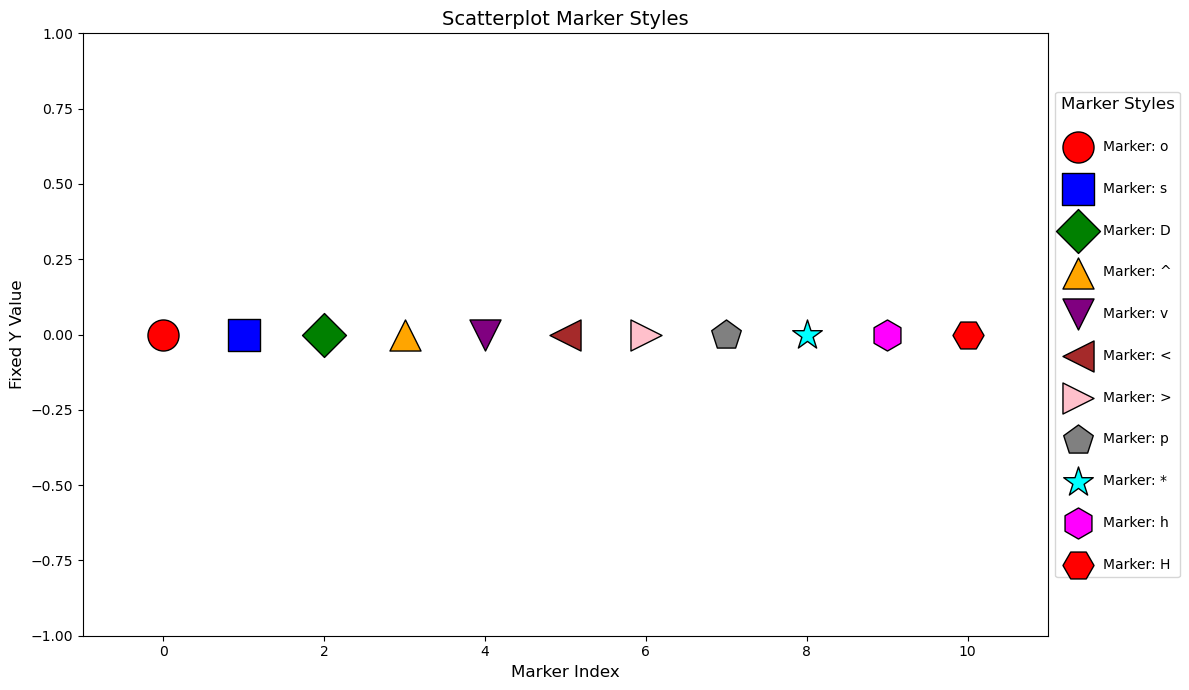

In [34]:
import matplotlib.pyplot as plt
import warnings

# Suppress specific warnings about edgecolor and facecolor
warnings.filterwarnings("ignore", message="You passed a edgecolor/edgecolors")

# Define marker styles
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']

# Create a figure
fig, ax = plt.subplots(figsize=(12, 7))  # Increased figure size for better layout

# Plot each marker style
for i, marker in enumerate(markers):
    ax.scatter(i, 0, s=500, c=colors[i % len(colors)], 
                edgecolors='black', marker=marker, label=f"Marker: {marker}")

# Add legend and labels
ax.legend(bbox_to_anchor=(1, 0.5), loc='center left', fontsize=10, title="Marker Styles", title_fontsize=12, labelspacing=2)
ax.set_xlim(-1, len(markers))
ax.set_ylim(-1, 1)
ax.set_title("Scatterplot Marker Styles", fontsize=14)
ax.set_xlabel("Marker Index", fontsize=12)
ax.set_ylabel("Fixed Y Value", fontsize=12)

plt.tight_layout()
plt.show()

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


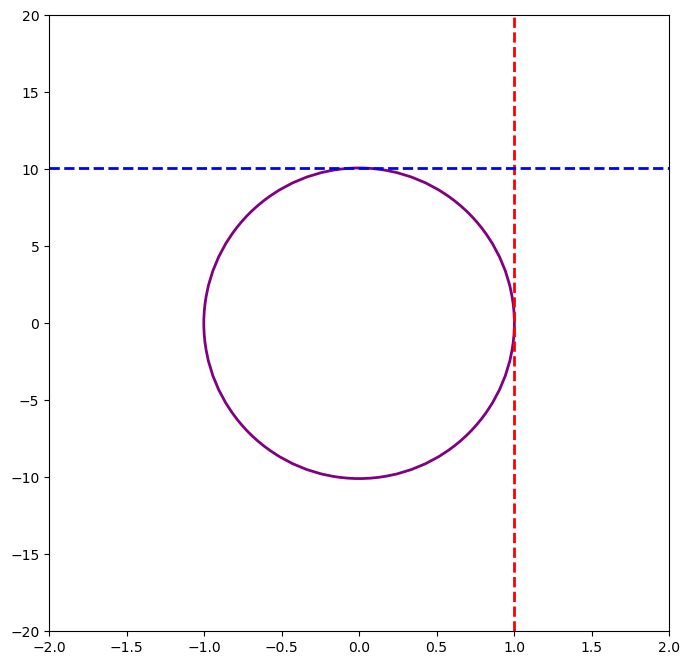

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

starting_point = (0, 0)
s = 50000

# Draw the circle
ax.scatter([starting_point[0]], [starting_point[1]], s=s, edgecolors=["purple"], 
           facecolors='none', marker='o', linewidths=2)

# s is in points^2, radius in points
radius_points = np.sqrt(s) / 2

# Convert points to pixels: points * (dpi / 72)
radius_pixels = radius_points * (fig.dpi / 72)

# Convert center to display (pixel) coordinates
center_display = ax.transData.transform([starting_point])

# Create points at radius distance in display coordinates
right_point_display = center_display + [[radius_pixels, 0]]
top_point_display = center_display + [[0, radius_pixels]]

# Convert back to data coordinates
right_point_data = ax.transData.inverted().transform(right_point_display)
top_point_data = ax.transData.inverted().transform(top_point_display)

# Extract the x and y coordinates for the tangent lines
x_tangent = right_point_data[0, 0]
y_tangent = top_point_data[0, 1]

print(f"Vertical tangent at x = {x_tangent}")
print(f"Horizontal tangent at y = {y_tangent}")

# Draw vertical and horizontal lines tangent to the scatterplot point
ax.axvline(x=x_tangent, color="red", linestyle="--", linewidth=2)
ax.axhline(y=y_tangent, color="blue", linestyle="--", linewidth=2)

plt.show()

Shape is a polygon. Returned vertices.


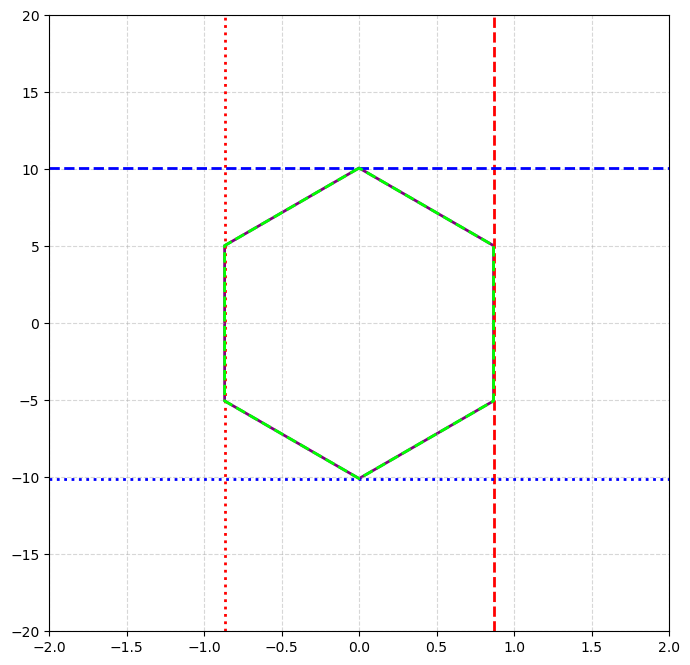

In [148]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.markers import MarkerStyle
from matplotlib.patches import Ellipse
from matplotlib.transforms import Affine2D

def get_marker_geometry(ax, marker, s, center_point=(0,0)):
    """
    Calculates the geometry of a matplotlib marker in data coordinates.

    Args:
        ax (matplotlib.axes.Axes): The axes object where the marker is plotted.
        marker (str): The marker style string (e.g., 'o', 's', 'h').
        s (float): The marker size in points^2, as used in plt.scatter.
        center_point (tuple, optional): The data coordinates of the marker's center.
                                        Defaults to (0,0).

    Returns:
        tuple: A tuple containing two elements:
               1. bounding_box (tuple): (x_min, x_max, y_min, y_max) for tangent lines.
               2. shape_data: For circles, a tuple (center, width, height) for an
                  ellipse. For other markers, a numpy array of vertex coordinates.
    """
    fig = ax.get_figure()
    fig.canvas.draw()

    # --- Method for Circle and Square (most reliable simple cases) ---
    if marker in ['o', 's']:
        radius_points = np.sqrt(s) / 2.0
        radius_pixels = radius_points * (fig.dpi / 72.0)
        center_display = ax.transData.transform([center_point])[0]

        right_point_data = ax.transData.inverted().transform([center_display + [radius_pixels, 0]])[0]
        left_point_data = ax.transData.inverted().transform([center_display - [radius_pixels, 0]])[0]
        top_point_data = ax.transData.inverted().transform([center_display + [0, radius_pixels]])[0]
        bottom_point_data = ax.transData.inverted().transform([center_display - [0, radius_pixels]])[0]

        bounding_box = (left_point_data[0], right_point_data[0], bottom_point_data[1], top_point_data[1])
        x_min, x_max, y_min, y_max = bounding_box

        if marker == 'o':
            ellipse_center = ((x_min + x_max) / 2.0, (y_min + y_max) / 2.0)
            ellipse_width = x_max - x_min
            ellipse_height = y_max - y_min
            shape_data = (ellipse_center, ellipse_width, ellipse_height)
        else: # marker == 's'
            shape_data = np.array([
                [x_min, y_min], [x_max, y_min], [x_max, y_max], [x_min, y_max]
            ])
        return bounding_box, shape_data

    # --- Method for All Other Polygon-based Markers ---
    else:
        # 1. Create a MarkerStyle object
        marker_obj = MarkerStyle(marker)

        # 2. Calculate the scaling factor to apply in pixel space
        # s is in points^2. The scale factor is sqrt(s) in points.
        # Convert points to pixels.
        pixel_scale = np.sqrt(s) * (fig.dpi / 72.0)

        # 3. Apply the scaling to the marker's transform
        # This uses the marker's own scaling logic.
        transform = marker_obj.get_transform().scale(pixel_scale)
        
        # 4. Get the final vertices in pixel space
        # The transform is applied to the base path.
        base_path = marker_obj.get_path()
        vertices_pixels = transform.transform_path(base_path).vertices

        # 5. Translate to the center point and convert to data coordinates
        center_display = ax.transData.transform([center_point])[0]
        vertices_pixels_final = vertices_pixels + center_display
        shape_data = ax.transData.inverted().transform(vertices_pixels_final)

        # 6. Define the bounding box from the final vertices
        x_min, x_max = np.min(shape_data[:, 0]), np.max(shape_data[:, 0])
        y_min, y_max = np.min(shape_data[:, 1]), np.max(shape_data[:, 1])
        bounding_box = (x_min, x_max, y_min, y_max)
        
        return bounding_box, shape_data



# --- Example Usage ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

starting_point = (0, 0)
s = 50000
marker_style = 'h' # Try 'o', 's', 'h', 'p', '*' etc.

# Draw the original marker
ax.scatter([starting_point[0]], [starting_point[1]], s=s, edgecolors=["purple"],
           facecolors='none', marker=marker_style, linewidths=2, label=f"Original Marker ('{marker_style}')")

# 1. Get the geometry from the new function
bounding_box, shape_data = get_marker_geometry(ax, marker_style, s, starting_point)
x_min, x_max, y_min, y_max = bounding_box

# 2. Draw the tangent lines from the bounding box
ax.axvline(x=x_max, color="red", linestyle="--", linewidth=2, label='Right Tangent')
ax.axvline(x=x_min, color="red", linestyle=":", linewidth=2, label='Left Tangent')
ax.axhline(y=y_max, color="blue", linestyle="--", linewidth=2, label='Top Tangent')
ax.axhline(y=y_min, color="blue", linestyle=":", linewidth=2, label='Bottom Tangent')

# 3. Draw the calculated shape based on its type
if marker_style == 'o':
    # For circles, unpack ellipse data and draw the ellipse
    center, width, height = shape_data
    ellipse = Ellipse(xy=center, width=width, height=height,
                      edgecolor='lime', facecolor='none', linestyle='--', linewidth=2,
                      label='Calculated Bounding Ellipse')
    ax.add_patch(ellipse)
    print("Shape is a circle. Returned ellipse parameters.")
else:
    # For other shapes, unpack vertices and draw the path
    vertices = shape_data
    closed_vertices = np.vstack([vertices, vertices[0]])
    ax.plot(closed_vertices[:, 0], closed_vertices[:, 1], 'lime', linestyle='--', linewidth=2, label='Calculated Path')
    print("Shape is a polygon. Returned vertices.")

# ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Minimum distance between markers: 0.0000 pixels
Overlap status: overlap


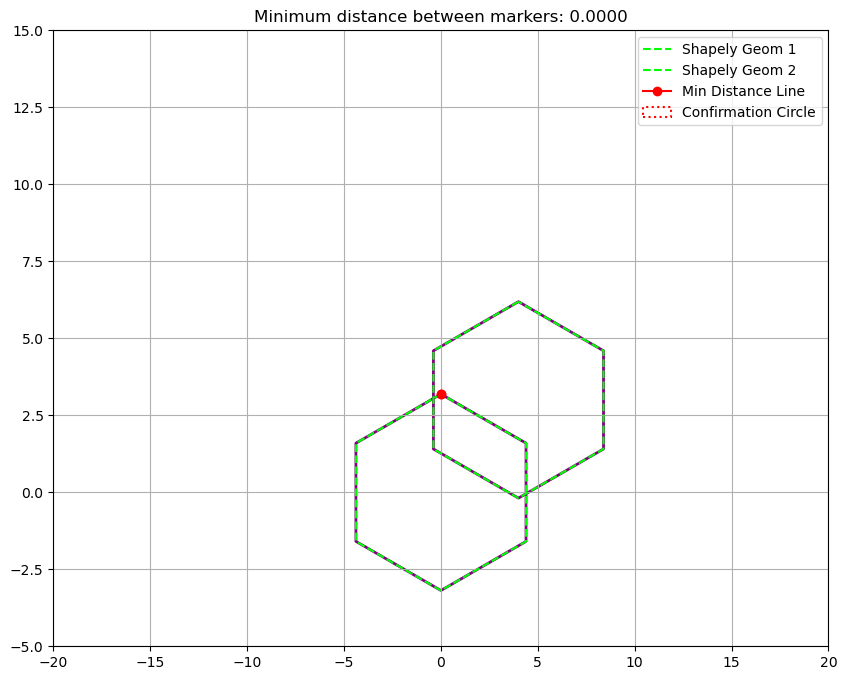

In [168]:
from shapely.geometry import Polygon, Point

def _get_shapely_geom(marker, shape_data):
    """Converts marker geometry data to a shapely object."""
    if marker == 'o':
        center, width, height = shape_data
        # For a circle/ellipse, create a point and buffer it.
        # Using the average of width and height as the buffer radius.
        radius = (width + height) / 4.0
        return Point(center).buffer(radius)
    else:
        # For other markers, create a polygon from the vertices.
        return Polygon(shape_data)

def calculate_marker_distance(p1, p2, s, marker, figsize, xlim, ylim):
    """
    Calculates the minimum distance between the boundaries of two markers.

    Args:
        p1 (tuple): The (x, y) coordinates of the first point.
        p2 (tuple): The (x, y) coordinates of the second point.
        s (float or tuple): The marker size(s) in points^2. If a single float,
                            it's used for both markers. If a tuple (s1, s2),
                            it specifies size for each.
        marker (str or tuple): The marker style(s). If a single string, it's
                               used for both. If a tuple (m1, m2), it specifies
                               style for each.
        figsize (tuple): The figure size (width, height) in inches.
        xlim (tuple): The x-axis limits for the plot.
        ylim (tuple): The y-axis limits for the plot.

    Returns:
        float: The minimum distance between the boundaries of the two markers
               in data coordinates. Returns 0 if they overlap.
    """
    # Create a temporary figure to perform coordinate transforms
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Handle arguments for s and marker
    s1, s2 = (s, s) if isinstance(s, (int, float)) else s
    marker1, marker2 = (marker, marker) if isinstance(marker, str) else marker

    # Get the geometry for both markers
    _, shape_data1 = get_marker_geometry(ax, marker1, s1, p1)
    _, shape_data2 = get_marker_geometry(ax, marker2, s2, p2)

    # Convert to shapely objects
    geom1 = _get_shapely_geom(marker1, shape_data1)
    geom2 = _get_shapely_geom(marker2, shape_data2)
    
    # Close the temporary figure to prevent it from displaying
    plt.close(fig)

    # Calculate and return the distance between the two shapely geometries
    return geom1.distance(geom2)

from shapely.ops import nearest_points

def get_marker_distance_and_points(p1, p2, s, marker, figsize, xlim, ylim):
    """
    Calculates the minimum distance and the closest points between two markers
    in DISPLAY (pixel) space to account for aspect ratio distortion.

    Args:
        p1 (tuple): The (x, y) coordinates of the first point.
        p2 (tuple): The (x, y) coordinates of the second point.
        s (float or tuple): The marker size(s) in points^2.
        marker (str or tuple): The marker style(s).
        figsize (tuple): The figure size (width, height) in inches.
        xlim (tuple): The x-axis limits for the plot.
        ylim (tuple): The y-axis limits for the plot.

    Returns:
        tuple: A tuple containing:
               - float: The minimum distance in pixel units.
               - tuple: The (x, y) data coordinates of the closest point on the first marker.
               - tuple: The (x, y) data coordinates of the closest point on the second marker.
               - str: Overlap status ('disjoint', 'tangent', or 'overlap').
    """
    # Create a temporary figure to perform coordinate transforms
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    fig.canvas.draw() # Ensure transforms are initialized

    # Handle arguments for s and marker
    s1, s2 = (s, s) if isinstance(s, (int, float)) else s
    marker1, marker2 = (marker, marker) if isinstance(marker, str) else marker

    # Get the geometry vertices in DATA coordinates
    _, shape_data1 = get_marker_geometry(ax, marker1, s1, p1)
    _, shape_data2 = get_marker_geometry(ax, marker2, s2, p2)

    # Transform vertices to DISPLAY (pixel) coordinates
    if marker1 == 'o': # Special handling for ellipse data
        center, width, height = shape_data1
        # Approximate ellipse with a polygon in data space first
        data_geom1 = Point(center).buffer(1)
        data_geom1 = data_geom1.boundary.coords
    else:
        data_geom1 = shape_data1
    
    if marker2 == 'o':
        center, width, height = shape_data2
        data_geom2 = Point(center).buffer(1)
        data_geom2 = data_geom2.boundary.coords
    else:
        data_geom2 = shape_data2

    display_geom1_verts = ax.transData.transform(data_geom1)
    display_geom2_verts = ax.transData.transform(data_geom2)

    # Create shapely objects in DISPLAY space
    geom1_disp = Polygon(display_geom1_verts)
    geom2_disp = Polygon(display_geom2_verts)
    
    # Close the temporary figure
    plt.close(fig)

    # Calculate distance and nearest points in DISPLAY space
    dist_pixels = geom1_disp.distance(geom2_disp)
    
    # Determine overlap status
    # Use a small tolerance for floating point comparisons
    if dist_pixels > 1e-9:
        overlap_status = 'disjoint'
    else:
        if geom1_disp.touches(geom2_disp):
            overlap_status = 'tangent'
        else: # This covers intersection, containment, etc.
            overlap_status = 'overlap'

    p_near1_disp, p_near2_disp = nearest_points(geom1_disp, geom2_disp)
    
    # Transform the nearest points back to DATA space for plotting
    p_near1_data = ax.transData.inverted().transform((p_near1_disp.x, p_near1_disp.y))
    p_near2_data = ax.transData.inverted().transform((p_near2_disp.x, p_near2_disp.y))
    
    return dist_pixels, tuple(p_near1_data), tuple(p_near2_data), overlap_status


# --- Example Usage ---
fig, ax = plt.subplots(figsize=(10, 8))
xlim = (-20, 20)
ylim = (-5, 15)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# --- Define two points ---
p1 = (0, 0)
p2 = (4, 3)
s_val = 20000
marker_val = 'h' # Try 'o', 'h', 'd', etc.
show_distance_circle = True # Option to draw a confirmation circle

# --- Calculate distance and closest points ---
figsize = fig.get_size_inches()
dist, p_near1, p_near2, overlap_status = get_marker_distance_and_points(p1, p2, s_val, marker_val, figsize, xlim, ylim)

print(f"Minimum distance between markers: {dist:.4f} pixels")
print(f"Overlap status: {overlap_status}")
# --- Visualization ---
# 1. Plot the markers
ax.scatter([p1[0], p2[0]], [p1[1], p2[1]], s=s_val, marker=marker_val,
           edgecolor='purple', facecolor='none', linewidth=2)

# 2. Get shapely geometries again for plotting (for verification)
_, shape_data1 = get_marker_geometry(ax, marker_val, s_val, p1)
_, shape_data2 = get_marker_geometry(ax, marker_val, s_val, p2)
geom1 = _get_shapely_geom(marker_val, shape_data1)
geom2 = _get_shapely_geom(marker_val, shape_data2)

# 3. Plot the shapely geometries to verify
ax.plot(*geom1.exterior.xy, color='lime', linestyle='--', label='Shapely Geom 1')
ax.plot(*geom2.exterior.xy, color='lime', linestyle='--', label='Shapely Geom 2')

# 4. Plot the line representing the minimum distance using the returned points
ax.plot([p_near1[0], p_near2[0]], [p_near1[1], p_near2[1]], 'r-o', label=f'Min Distance Line')

# 5. Optionally, draw a circle to confirm the distance
if show_distance_circle:
    from matplotlib.patches import Ellipse

    # To draw a shape that appears as a circle in display space, we must
    # calculate the radius in pixels and then create an Ellipse patch in
    # data space that accounts for the plot's aspect ratio.

    # 1. Transform nearest points to display (pixel) coordinates
    p1_disp = ax.transData.transform(p_near1)
    p2_disp = ax.transData.transform(p_near2)

    # 2. Calculate the radius in pixel units
    radius_pixels = np.sqrt((p2_disp[0] - p1_disp[0])**2 + (p2_disp[1] - p1_disp[1])**2)

    # 3. Calculate the ellipse width and height in data units that correspond to the pixel radius
    # Find the data coordinates of a point that is `radius_pixels` to the right of p_near1
    right_point_disp = p1_disp + [radius_pixels, 0]
    right_point_data = ax.transData.inverted().transform(right_point_disp)
    
    # Find the data coordinates of a point that is `radius_pixels` above p_near1
    top_point_disp = p1_disp + [0, radius_pixels]
    top_point_data = ax.transData.inverted().transform(top_point_disp)

    # The width and height of the ellipse are twice the difference in data coordinates
    ellipse_width = (right_point_data[0] - p_near1[0]) * 2
    ellipse_height = (top_point_data[1] - p_near1[1]) * 2

    # 4. Create an Ellipse patch that will appear as a circle
    confirmation_ellipse = Ellipse(
        xy=p_near1,
        width=ellipse_width,
        height=ellipse_height,
        color='red',
        fill=False,
        linestyle=':',
        linewidth=1.5,
        label='Confirmation Circle'
    )
    ax.add_patch(confirmation_ellipse)

ax.set_title(f"Minimum distance between markers: {dist:.4f}")
ax.legend()
plt.grid(True)
plt.show()

Shape is a circle. Returned ellipse parameters.


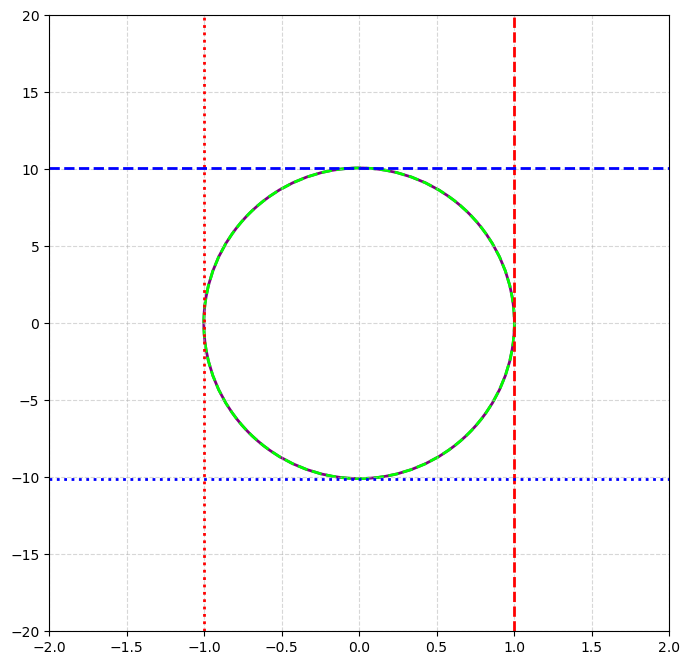

Shape is a polygon. Returned vertices.


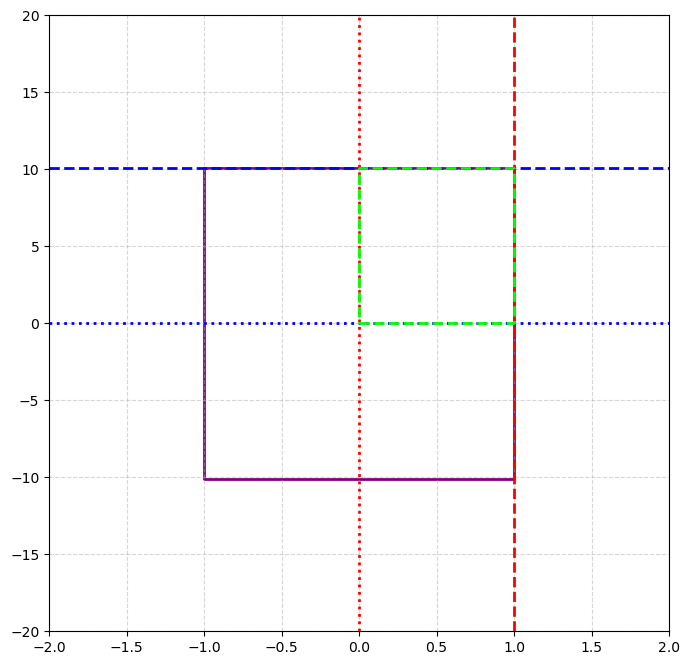

Shape is a polygon. Returned vertices.


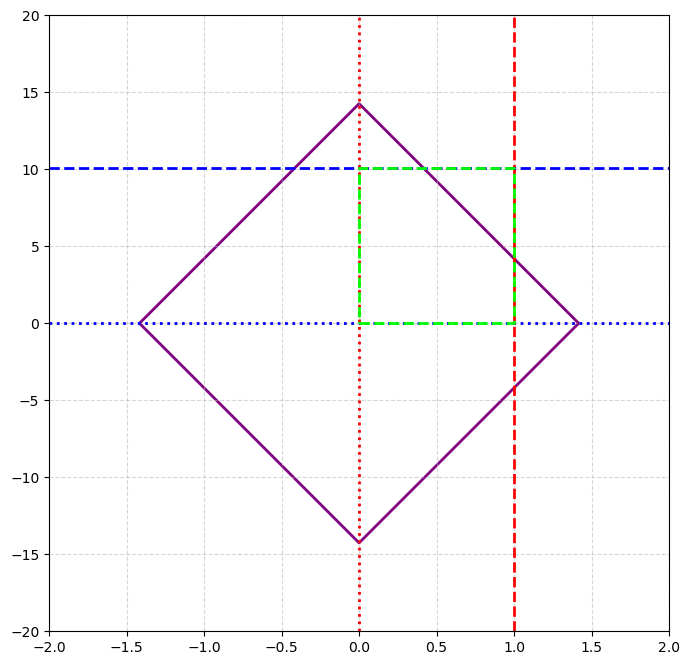

Shape is a polygon. Returned vertices.


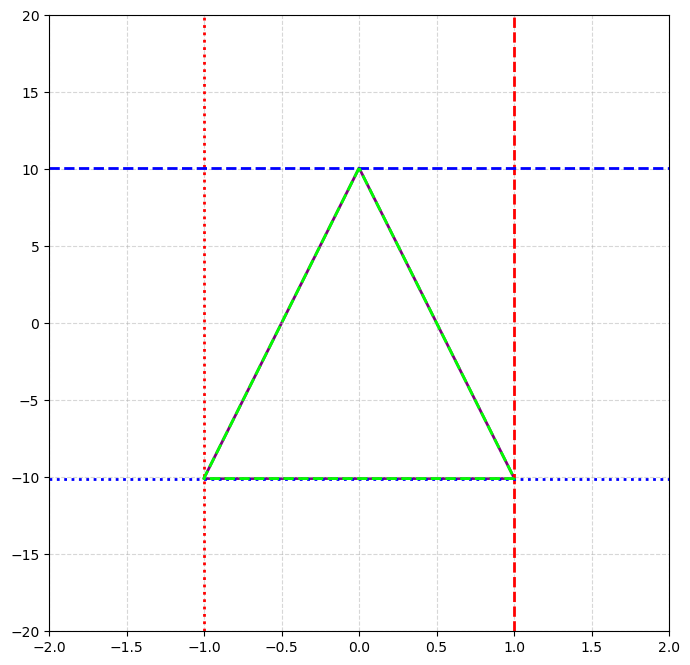

Shape is a polygon. Returned vertices.


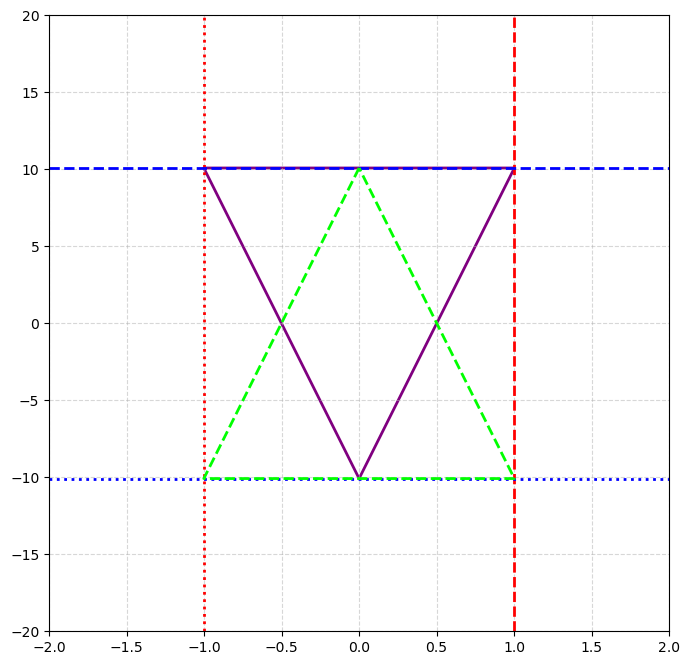

Shape is a polygon. Returned vertices.


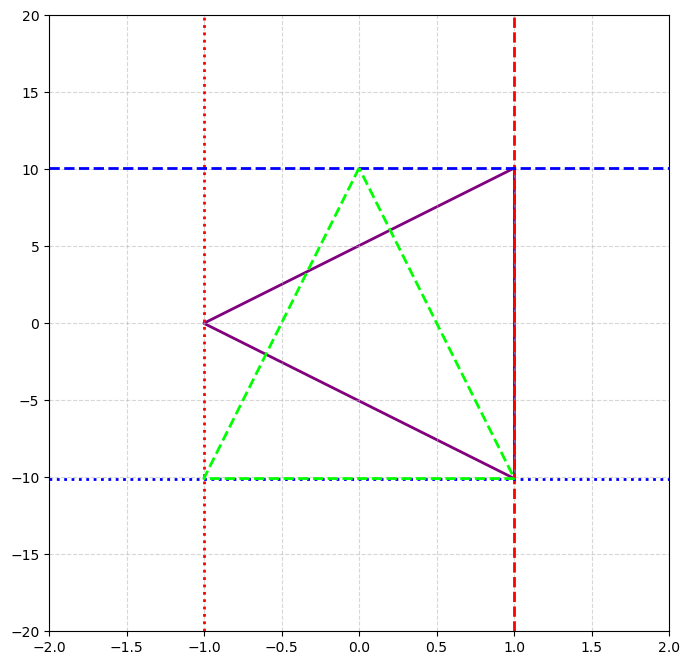

Shape is a polygon. Returned vertices.


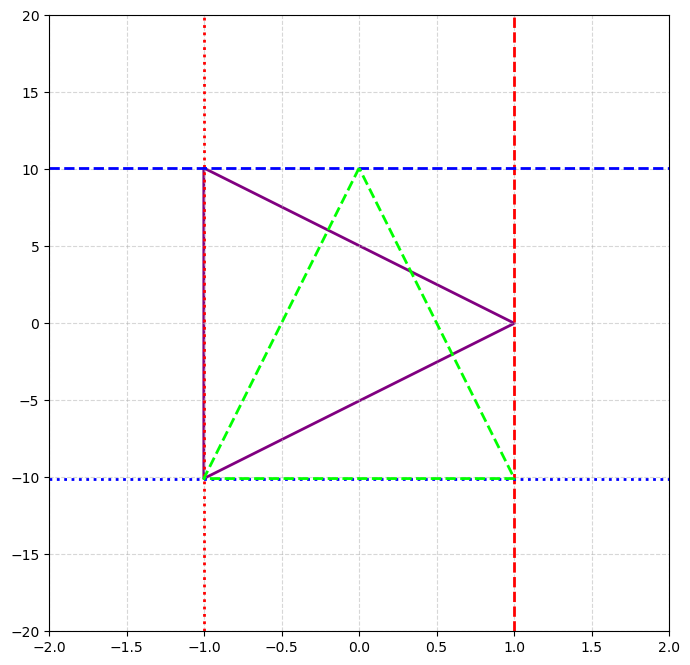

Shape is a polygon. Returned vertices.


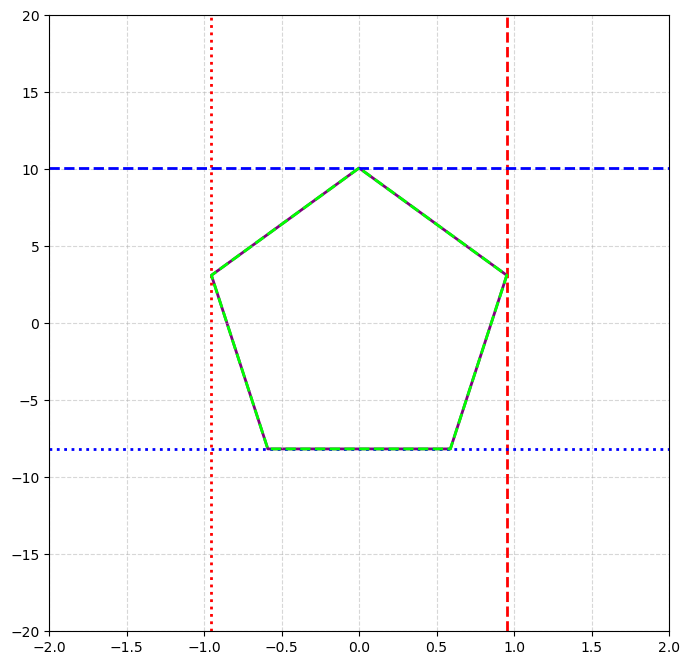

Shape is a polygon. Returned vertices.


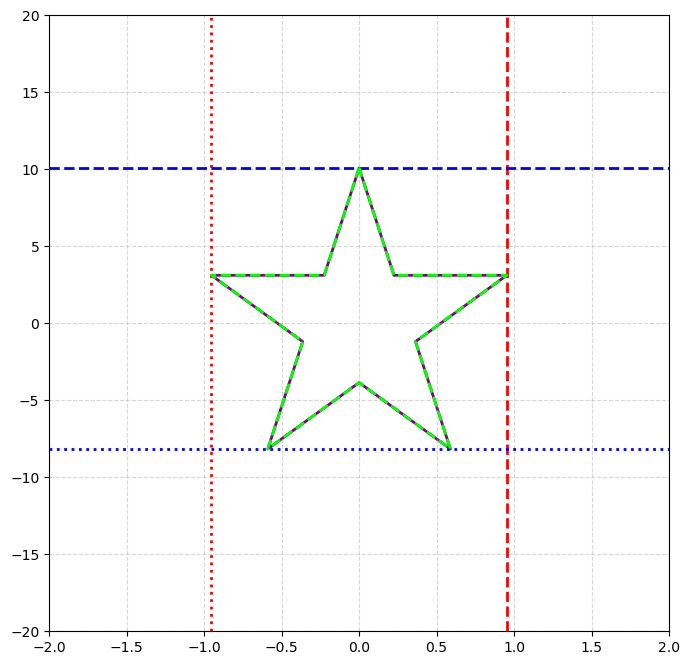

Shape is a polygon. Returned vertices.


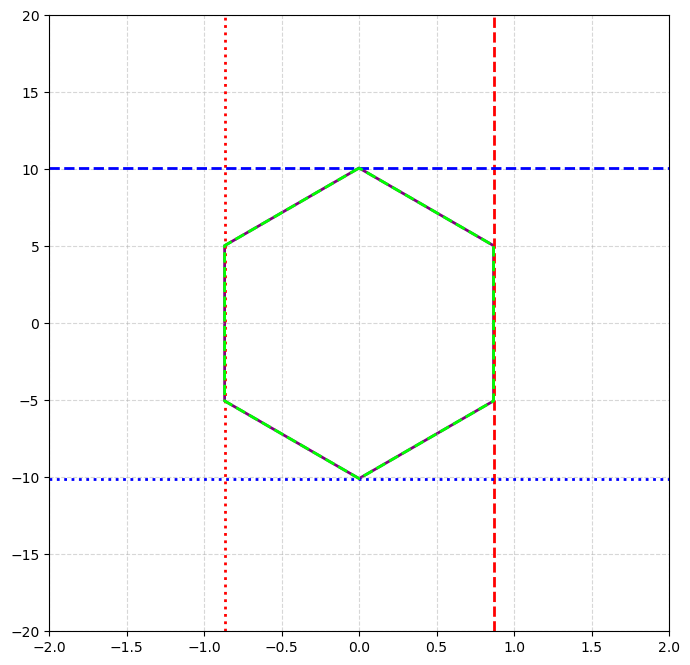

Shape is a polygon. Returned vertices.


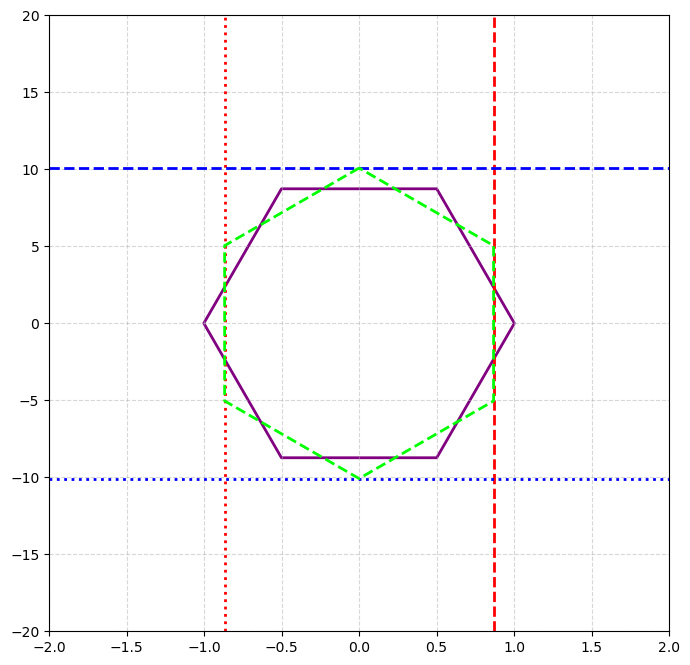

In [104]:
for marker in ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H']:
    # --- Example Usage ---
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2, 2)
    ax.set_ylim(-20, 20)

    starting_point = (0, 0)
    s = 50000
    marker_style = marker # Try 'o', 's', 'h', 'p', '*' etc.

    # Draw the original marker
    ax.scatter([starting_point[0]], [starting_point[1]], s=s, edgecolors=["purple"],
            facecolors='none', marker=marker_style, linewidths=2, label=f"Original Marker ('{marker_style}')")

    # 1. Get the geometry from the new function
    bounding_box, shape_data = get_marker_geometry(ax, marker_style, s, starting_point)
    x_min, x_max, y_min, y_max = bounding_box

    # 2. Draw the tangent lines from the bounding box
    ax.axvline(x=x_max, color="red", linestyle="--", linewidth=2, label='Right Tangent')
    ax.axvline(x=x_min, color="red", linestyle=":", linewidth=2, label='Left Tangent')
    ax.axhline(y=y_max, color="blue", linestyle="--", linewidth=2, label='Top Tangent')
    ax.axhline(y=y_min, color="blue", linestyle=":", linewidth=2, label='Bottom Tangent')

    # 3. Draw the calculated shape based on its type
    if marker_style == 'o':
        # For circles, unpack ellipse data and draw the ellipse
        center, width, height = shape_data
        ellipse = Ellipse(xy=center, width=width, height=height,
                        edgecolor='lime', facecolor='none', linestyle='--', linewidth=2,
                        label='Calculated Bounding Ellipse')
        ax.add_patch(ellipse)
        print("Shape is a circle. Returned ellipse parameters.")
    else:
        # For other shapes, unpack vertices and draw the path
        vertices = shape_data
        closed_vertices = np.vstack([vertices, vertices[0]])
        ax.plot(closed_vertices[:, 0], closed_vertices[:, 1], 'lime', linestyle='--', linewidth=2, label='Calculated Path')
        print("Shape is a polygon. Returned vertices.")

    # ax.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


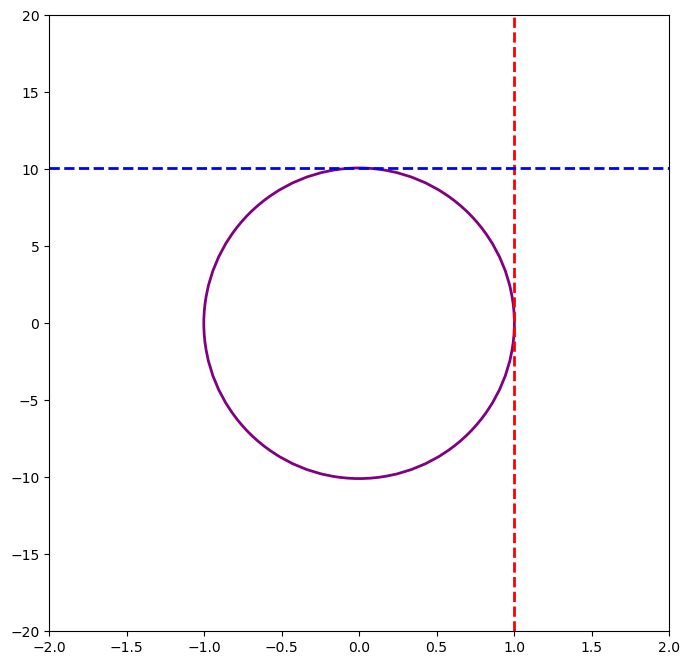

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


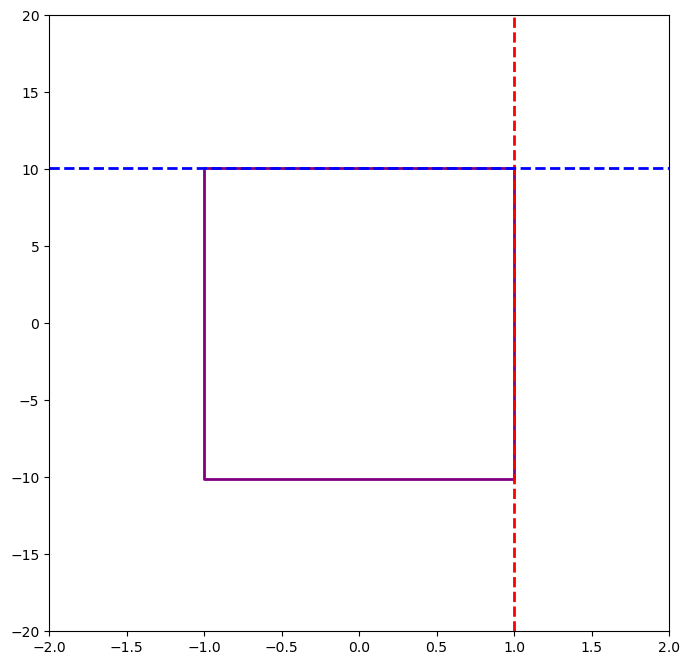

Vertical tangent at x = 1.416791066383683
Horizontal tangent at y = 14.259910083731874


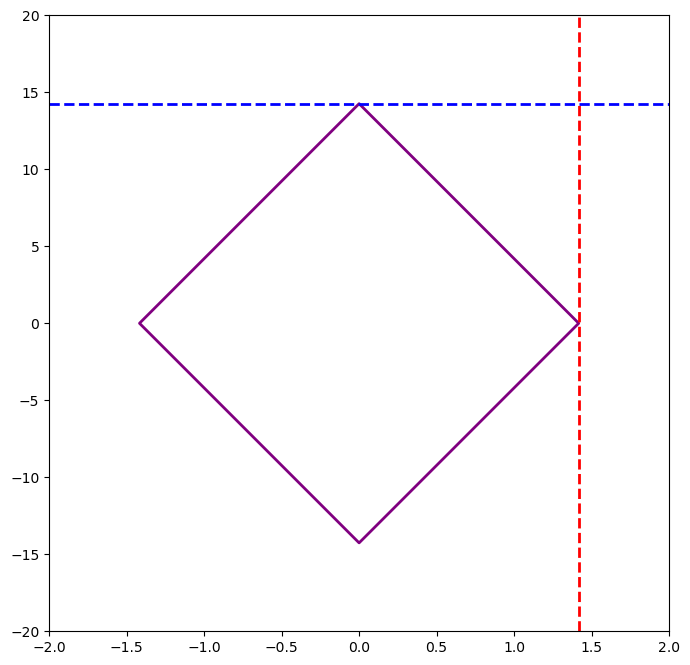

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


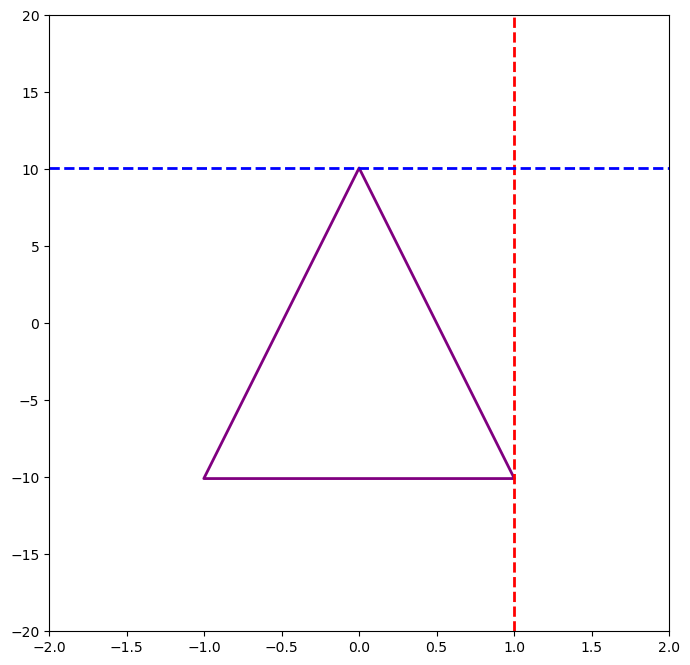

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


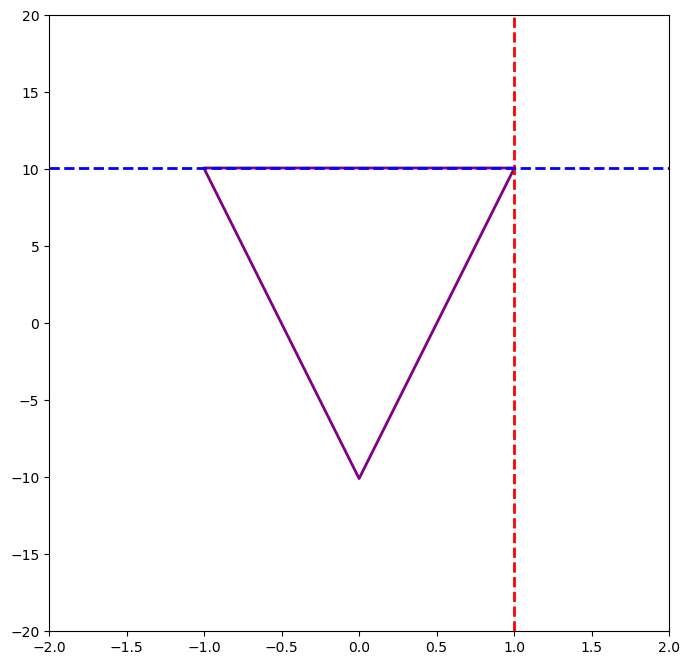

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


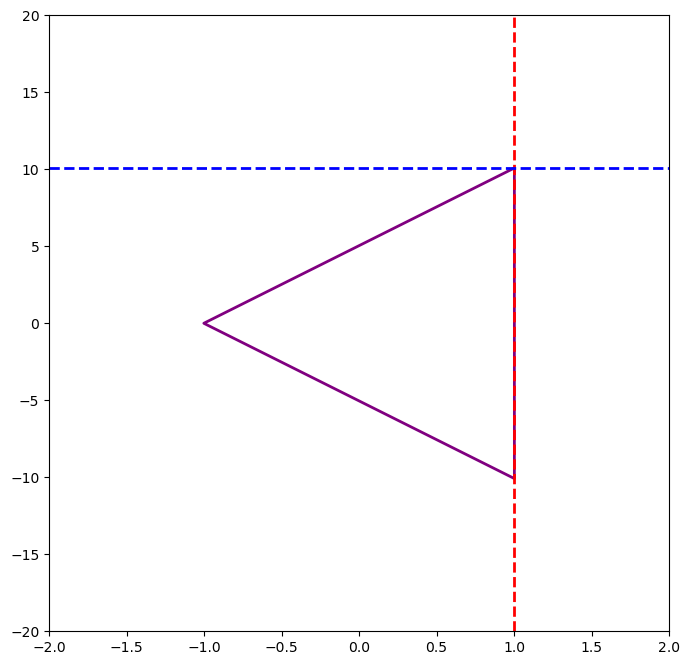

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


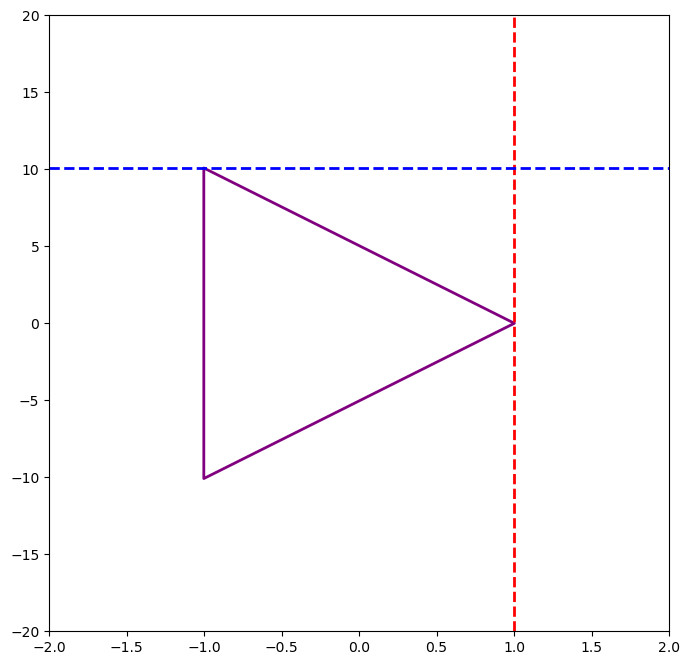

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


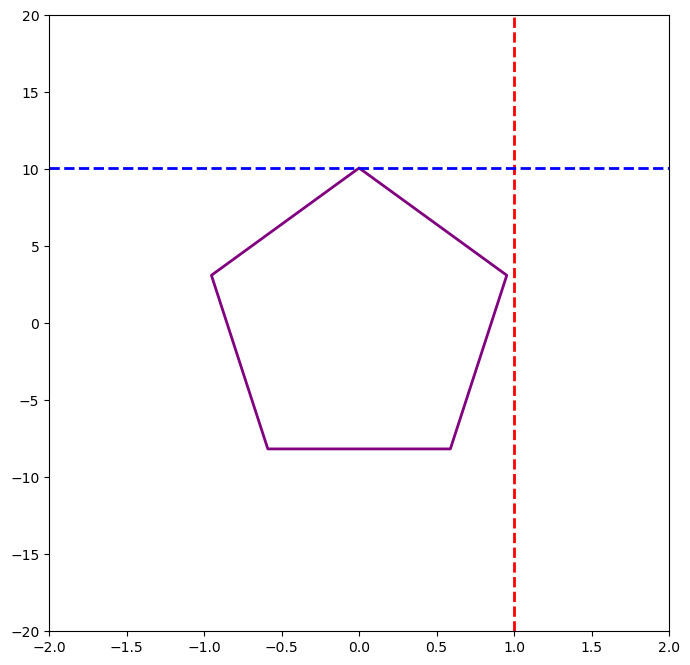

Vertical tangent at x = 1.0018225705644221
Horizontal tangent at y = 10.08327911931724


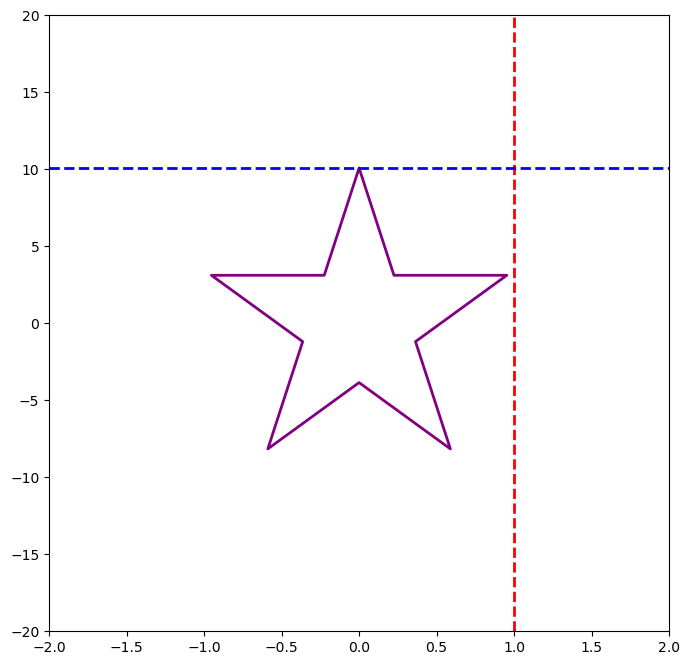

Vertical tangent at x = 1.1520959561490849
Horizontal tangent at y = 11.59577098721482


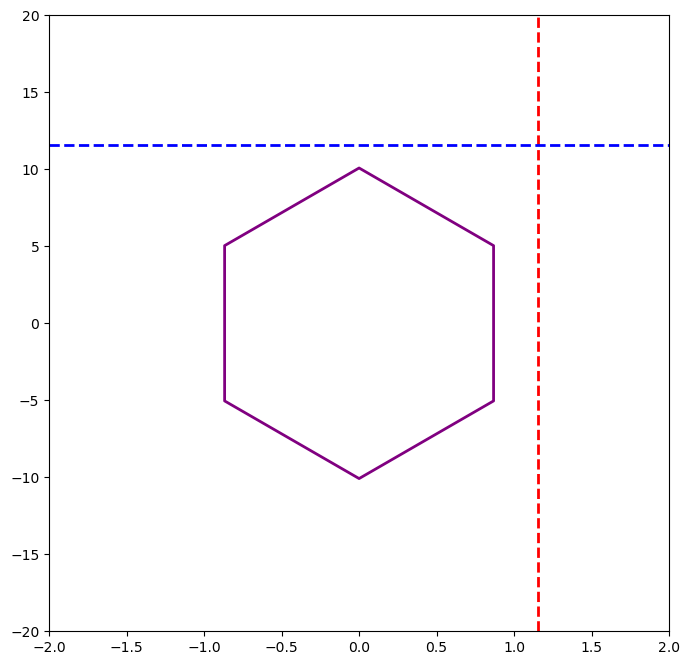

Vertical tangent at x = 1.1520959561490849
Horizontal tangent at y = 11.59577098721482


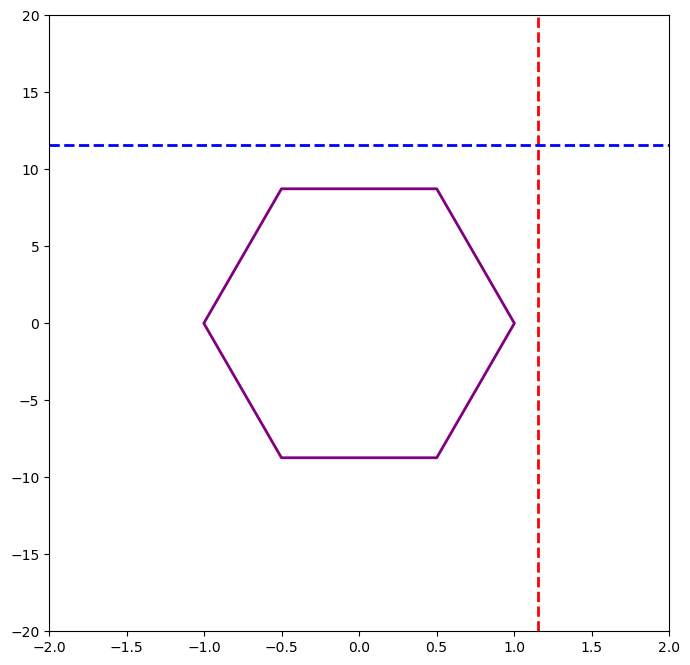

In [43]:
for marker in ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H']:

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2, 2)
    ax.set_ylim(-20, 20)

    starting_point = (0, 0)
    s = 50000

    # Draw the circle
    ax.scatter([starting_point[0]], [starting_point[1]], s=s, edgecolors=["purple"], 
            facecolors='none', marker=marker, linewidths=2)

    # s is in points^2, radius in points
    radius_points = np.sqrt(s) / 2

    # Convert points to pixels: points * (dpi / 72)
    right_radius_pixels = radius_points * (fig.dpi / 72)
    top_radius_pixels = radius_points * (fig.dpi / 72)
    if marker == 'D':
        # For a diamond (rotated square), the extent along x and y axes is radius * sqrt(2)
        right_radius_pixels = right_radius_pixels * np.sqrt(2)
        top_radius_pixels = top_radius_pixels * np.sqrt(2)
    elif marker == 'h' or marker == 'H':
        # For hexagon, approximate adjustment
        right_radius_pixels = right_radius_pixels * 1.15
        top_radius_pixels = top_radius_pixels * 1.15

    # Convert center to display (pixel) coordinates
    center_display = ax.transData.transform([starting_point])

    # Create points at radius distance in display coordinates
    right_point_display = center_display + [[right_radius_pixels, 0]]
    top_point_display = center_display + [[0, top_radius_pixels]]

    # Convert back to data coordinates
    right_point_data = ax.transData.inverted().transform(right_point_display)
    top_point_data = ax.transData.inverted().transform(top_point_display)

    # Extract the x and y coordinates for the tangent lines
    x_tangent = right_point_data[0, 0]
    y_tangent = top_point_data[0, 1]

    print(f"Vertical tangent at x = {x_tangent}")
    print(f"Horizontal tangent at y = {y_tangent}")

    # Draw vertical and horizontal lines tangent to the scatterplot point
    ax.axvline(x=x_tangent, color="red", linestyle="--", linewidth=2)
    ax.axhline(y=y_tangent, color="blue", linestyle="--", linewidth=2)

    plt.show()

Calculated s: 15528.153599999998


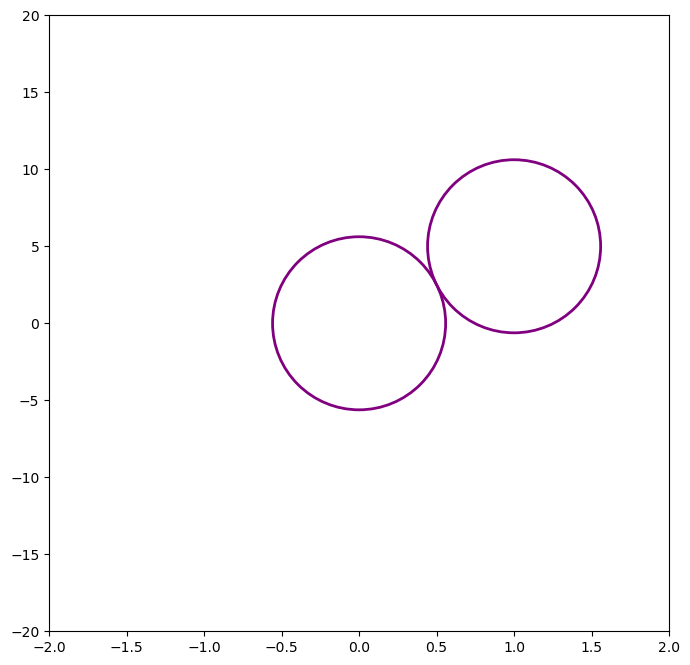

Calculated s: 15528.153599999998


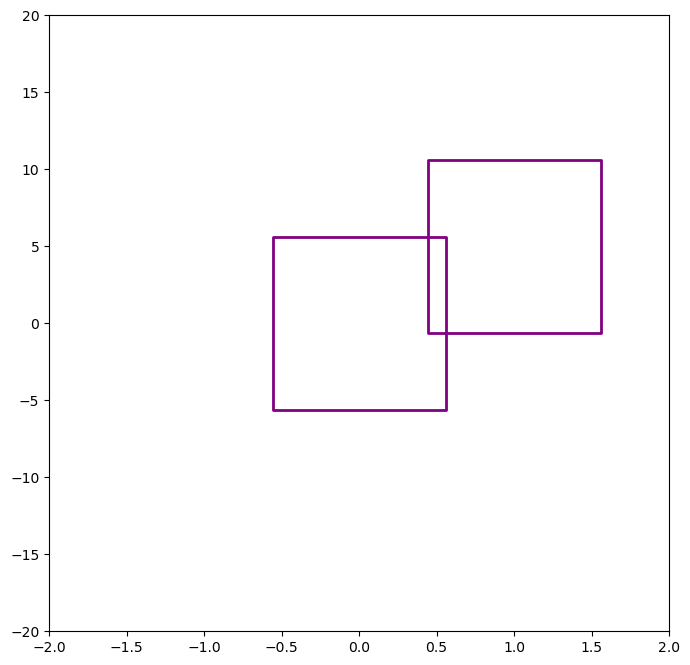

Calculated s: 15528.153599999998


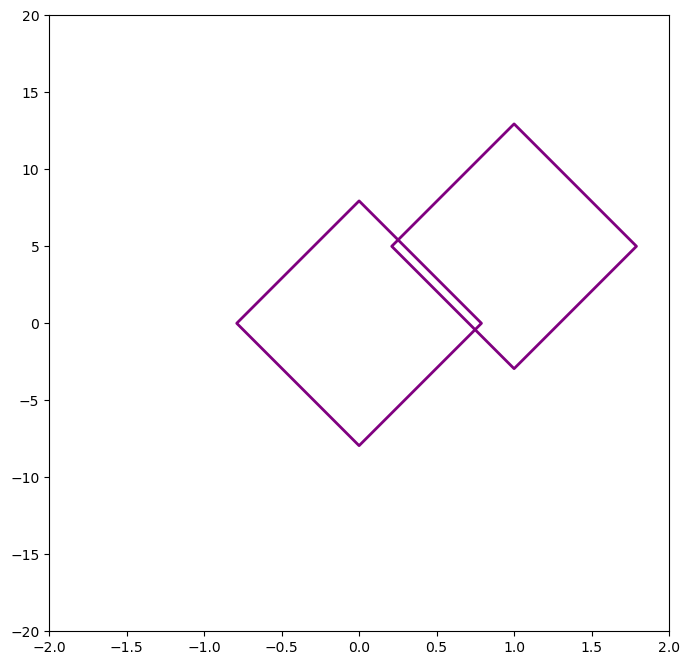

Calculated s: 15528.153599999998


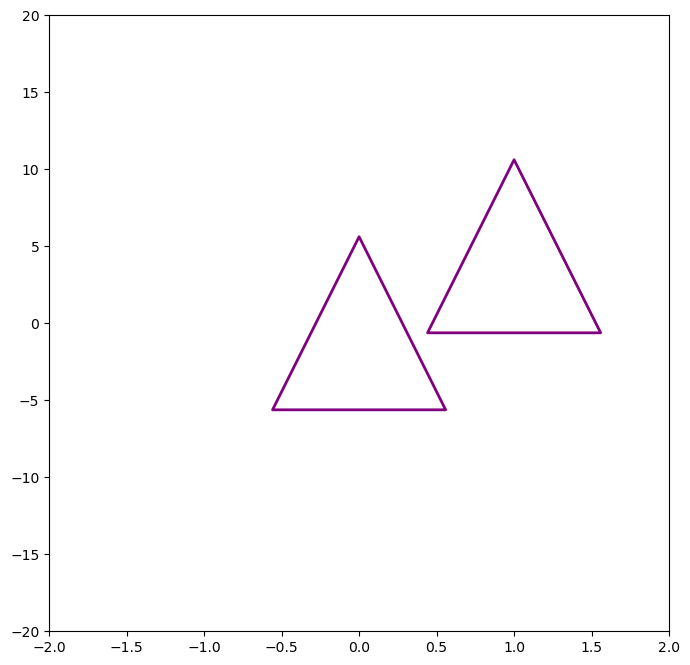

Calculated s: 15528.153599999998


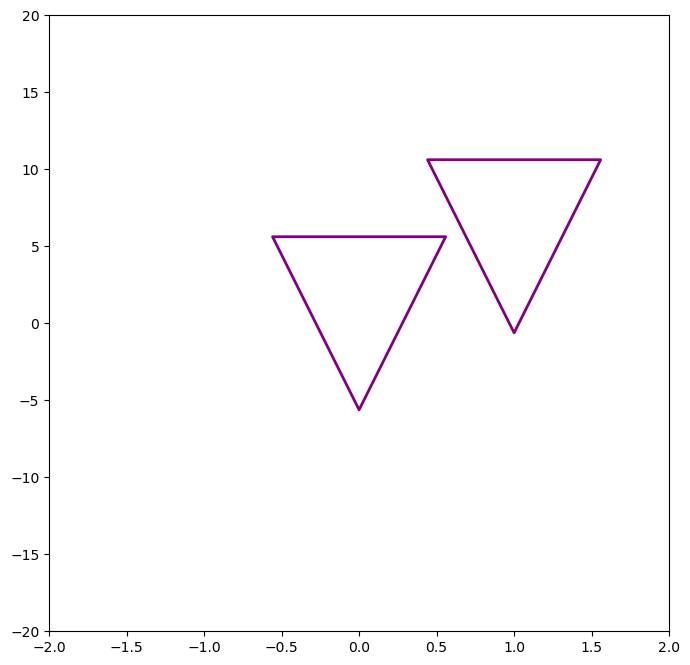

Calculated s: 15528.153599999998


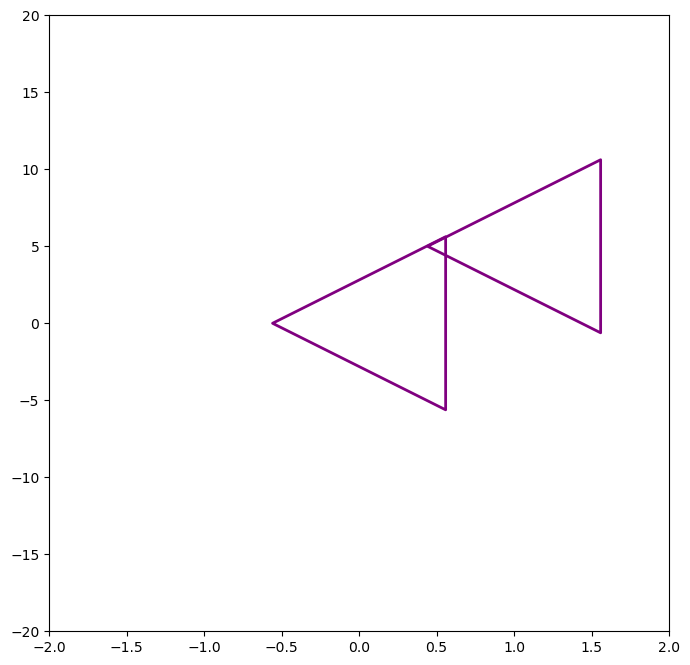

Calculated s: 15528.153599999998


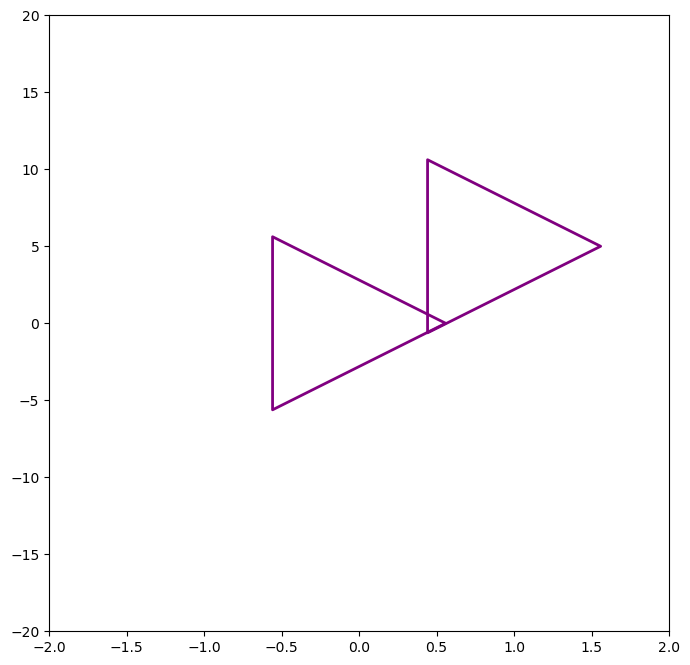

Calculated s: 15528.153599999998


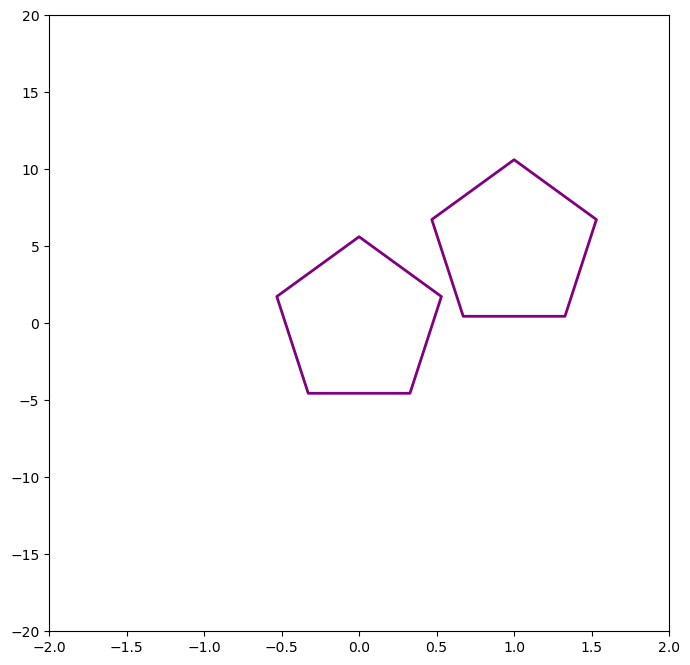

Calculated s: 15528.153599999998


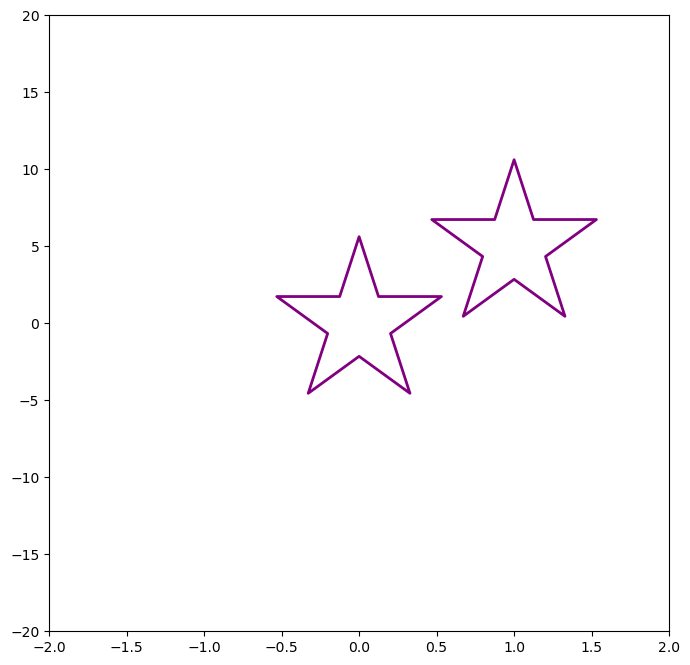

Calculated s: 15528.153599999998


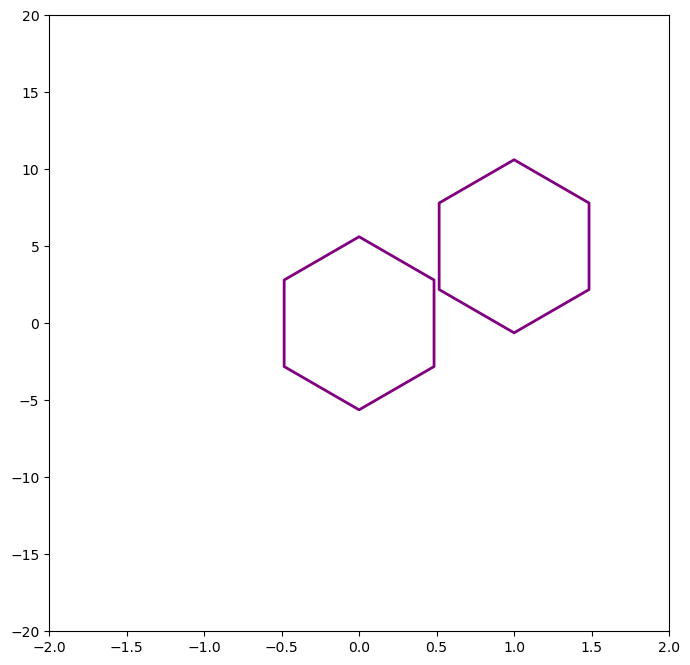

Calculated s: 15528.153599999998


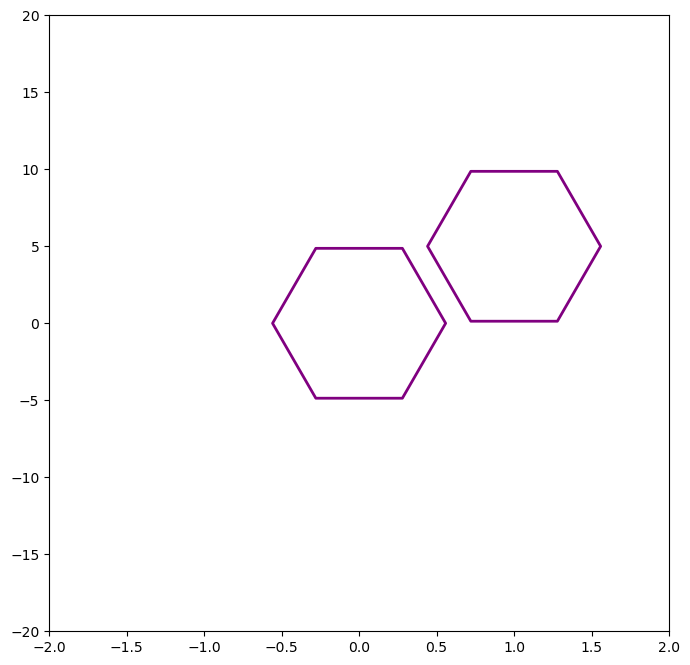

In [42]:
import matplotlib.pyplot as plt
import numpy as np
for marker in ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H']:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-2, 2)
    ax.set_ylim(-20, 20)

    pt_1 = (0, 0)
    pt_2 = (1, 5)

    def calculate_s(p1, p2, fig, ax):
        # Convert both points to display (pixel) coordinates
        p1_display = ax.transData.transform([p1])[0]
        p2_display = ax.transData.transform([p2])[0]
        
        # Calculate distance between points in pixels
        distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                                (p2_display[1] - p1_display[1])**2)
        
        # For two circles to be tangent, distance = 2 * radius
        # So radius in pixels = distance / 2
        radius_pixels = distance_pixels / 2
        
        # Convert pixels back to points: pixels / (dpi / 72)
        radius_points = radius_pixels / (fig.dpi / 72)
        
        # s = (diameter in points)^2 = (2 * radius)^2
        s = (2 * radius_points) ** 2
        
        return s

    s = calculate_s(pt_1, pt_2, fig, ax)
    print(f"Calculated s: {s}")

    ax.scatter([pt_1[0], pt_2[0]], [pt_1[1], pt_2[1]], s=s, edgecolors=["purple"], 
            facecolors='none', marker=marker, linewidths=2)

    plt.show()

Points are overlapping. Calculating shift.
       xnew  ynew  xorig  yorig   color
0  0.000000     0      0      0  purple
1  0.388217     1      0      1  purple


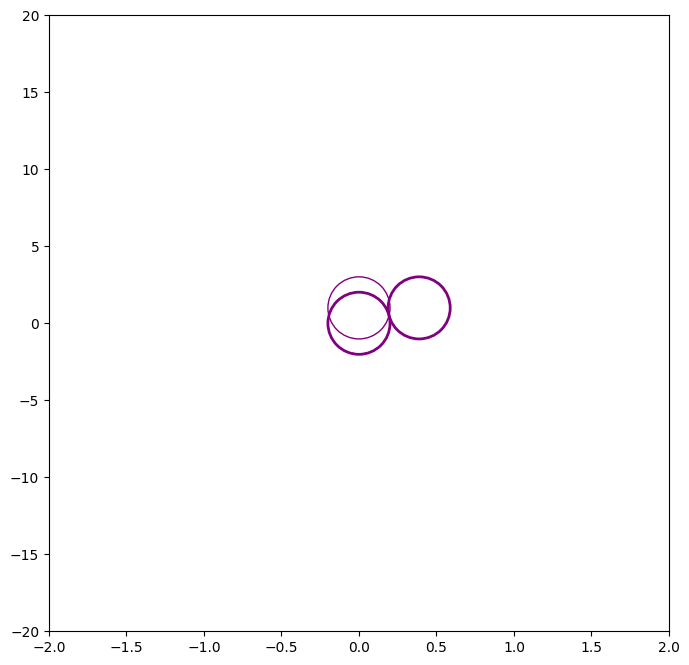

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

pt_1 = (0, 0)
pt_2 = (0, 1)
s = 2000


def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels

def calculate_shift(p1, p2, s, fig, ax):
    # Calculate how much we need to shift p2 horizontally to make the points just touch
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # For circles to just touch: distance between centers = 2 * radius
    target_distance_pixels = 2 * radius_pixels
    
    # Current distance in y-direction (display coordinates)
    dy_pixels = p2_display[1] - p1_display[1]
    
    # We need: sqrt(dx^2 + dy^2) = target_distance
    # So: dx^2 = target_distance^2 - dy^2
    dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
    
    if dx_pixels_squared < 0:
        # If dy alone is already > target_distance, we can't make them tangent with horizontal shift alone
        # In this case, shift to put them side by side
        dx_pixels = target_distance_pixels
    else:
        dx_pixels = np.sqrt(dx_pixels_squared)
    
    # Create the new position in display coordinates
    new_p2_display = np.array([p1_display[0] + dx_pixels, p2_display[1]])
    
    # Convert back to data coordinates
    new_p2_data = ax.transData.inverted().transform([new_p2_display])[0]
    
    # Calculate the shift needed in x-direction
    shift_x = new_p2_data[0] - p2[0]
    
    return shift_x

def calculate_shifted_point(p1, p2, s, fig, ax):
    # Transform points to display coordinates
    dist_pts = estimate_distance_data_units(p1, p2, s, fig, ax)
    if dist_pts > 0:
        print("Points are not overlapping.")
        bs = pd.DataFrame({
            "xnew": [p1[0], p2[0]],
            "ynew": [p1[1], p2[1]],
            "xorig": [p1[0], p2[0]],
            "yorig": [p1[1], p2[1]],
            "color": ["purple", "purple"]
        })
    else:
        # Calculate how much we need to add to the first coordinate of p2 to make the points just touch
        print("Points are overlapping. Calculating shift.")
        shift_needed = calculate_shift(p1, p2, s, fig, ax)
        new_p2 = (p2[0] + shift_needed, p2[1])
        bs = pd.DataFrame({
            "xnew": [p1[0], new_p2[0]],
            "ynew": [p1[1], new_p2[1]],
            "xorig": [p1[0], p2[0]],
            "yorig": [p1[1], p2[1]],
            "color": ["purple", "purple"]
        })
    return bs

bs = calculate_shifted_point(pt_1, pt_2, s, fig, ax)
print(bs)

ax.scatter(bs['xorig'], bs['yorig'], s=s, edgecolors=bs['color'], 
           facecolors='none', marker='o', linewidths=1, linestyle='-')
ax.scatter(bs['xnew'], bs['ynew'], s=s, edgecolors=bs['color'], 
           facecolors='none', marker='o', linewidths=2)


plt.show()

Points are overlapping. Calculating shift.

Evaluating shifts for new point at (0, 1.05)

Tangent To   Direction  Shift        |Shift|      Valid    Overlaps With
----------------------------------------------------------------------
Point 0      right          0.3869      0.3869  ✗ NO     [1]
Point 0      left          -0.3869      0.3869  ✓ YES    -
Point 1      right          0.7889      0.7889  ✗ NO     [1]
Point 1      left          -0.0125      0.0125  ✗ NO     [0, 1]

✓ CHOSEN: Shift left of point 0
  Shift amount: -0.3869
  Distance from original: 0.3869
  New position: (-0.3869, 1.0500)



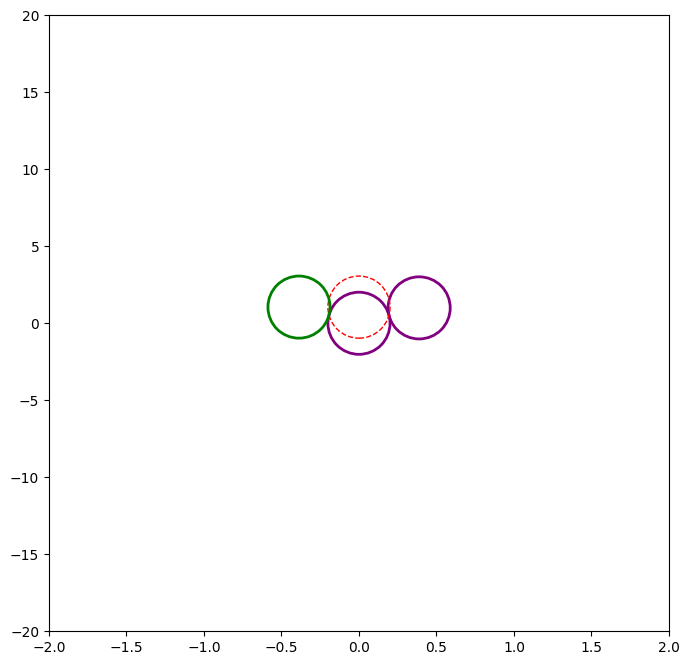

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

pt_1 = (0, 0)
pt_2 = (0, 1)
s = 2000


def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels

def calculate_shift(p1, p2, s, fig, ax):
    # Calculate how much we need to shift p2 horizontally to make the points just touch
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # For circles to just touch: distance between centers = 2 * radius
    target_distance_pixels = 2 * radius_pixels
    
    # Current distance in y-direction (display coordinates)
    dy_pixels = p2_display[1] - p1_display[1]
    
    # We need: sqrt(dx^2 + dy^2) = target_distance
    # So: dx^2 = target_distance^2 - dy^2
    dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
    
    if dx_pixels_squared < 0:
        # If dy alone is already > target_distance, we can't make them tangent with horizontal shift alone
        # In this case, shift to put them side by side
        dx_pixels = target_distance_pixels
    else:
        dx_pixels = np.sqrt(dx_pixels_squared)
    
    # Create the new position in display coordinates
    new_p2_display = np.array([p1_display[0] + dx_pixels, p2_display[1]])
    
    # Convert back to data coordinates
    new_p2_data = ax.transData.inverted().transform([new_p2_display])[0]
    
    # Calculate the shift needed in x-direction
    shift_x = new_p2_data[0] - p2[0]
    
    return shift_x

def calculate_shifted_point(p1, p2, s, fig, ax):
    # Transform points to display coordinates
    dist_pts = estimate_distance_data_units(p1, p2, s, fig, ax)
    if dist_pts > 0:
        print("Points are not overlapping.")
        bs = pd.DataFrame({
            "xnew": [p1[0], p2[0]],
            "ynew": [p1[1], p2[1]],
            "xorig": [p1[0], p2[0]],
            "yorig": [p1[1], p2[1]],
            "color": ["purple", "purple"]
        })
    else:
        # Calculate how much we need to add to the first coordinate of p2 to make the points just touch
        print("Points are overlapping. Calculating shift.")
        shift_needed = calculate_shift(p1, p2, s, fig, ax)
        new_p2 = (p2[0] + shift_needed, p2[1])
        bs = pd.DataFrame({
            "xnew": [p1[0], new_p2[0]],
            "ynew": [p1[1], new_p2[1]],
            "xorig": [p1[0], p2[0]],
            "yorig": [p1[1], p2[1]],
            "color": ["purple", "purple"]
        })
    return bs

bs = calculate_shifted_point(pt_1, pt_2, s, fig, ax)

points = pd.DataFrame({
    'xorig': bs['xorig'],
    'yorig': bs['yorig'],
    'xnew': bs['xnew'],
    'ynew': bs['ynew']
})

new_pt = (0, 1.05)


def check_overlap(pt1, pt2, s, fig, ax):
    """Check if two points overlap (returns True if they overlap)"""
    edge_dist = estimate_distance_data_units(pt1, pt2, s, fig, ax)
    return edge_dist < 0


def calculate_shift_for_new_point(new_pt, existing_points, s, fig, ax):
    """
    Calculate the minimum horizontal shift needed for new_pt to:
    1. Not overlap with any existing point
    2. Be tangent to at least one existing point
    3. Move as little as possible
    
    Strategy: For each existing point, calculate where new_pt would need to be
    to be tangent on the left and on the right. Then check if that position
    is valid (doesn't overlap with any other points). Pick the valid position
    that requires the smallest shift.
    """
    # Convert new point to display coordinates
    new_pt_display = ax.transData.transform([new_pt])[0]
    
    # Calculate radius in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    target_distance_pixels = 2 * radius_pixels
    
    all_candidates = []
    valid_shifts = []
    
    print(f"\n{'='*70}")
    print(f"Evaluating shifts for new point at {new_pt}")
    print(f"{'='*70}\n")
    
    # For each existing point
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        existing_pt_display = ax.transData.transform([existing_pt])[0]
        
        # Calculate dy in display coordinates
        dy_pixels = new_pt_display[1] - existing_pt_display[1]
        
        # Calculate required dx for tangency: sqrt((2*r)^2 - dy^2)
        dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
        
        if dx_pixels_squared < 0:
            # Points are too far apart vertically to be tangent with horizontal shift
            print(f"Point {idx} at {existing_pt}: Too far apart vertically (dy={dy_pixels:.2f}px)")
            continue
        
        dx_pixels = np.sqrt(dx_pixels_squared)
        
        # Try both left and right of this existing point
        for sign, direction in [(1, "right"), (-1, "left")]:
            # Calculate where new point would be
            new_pt_candidate_display = np.array([
                existing_pt_display[0] + sign * dx_pixels, 
                new_pt_display[1]
            ])
            new_pt_candidate_data = ax.transData.inverted().transform([new_pt_candidate_display])[0]
            candidate_position = (new_pt_candidate_data[0], new_pt[1])
            shift_candidate = new_pt_candidate_data[0] - new_pt[0]
            
            # Check if this position overlaps with ANY existing point
            is_valid = True
            overlaps_with = []
            for idx2, row2 in existing_points.iterrows():
                existing_pt2 = (row2['xnew'], row2['ynew'])
                if check_overlap(candidate_position, existing_pt2, s, fig, ax):
                    is_valid = False
                    overlaps_with.append(idx2)
            
            candidate_info = {
                'tangent_to_idx': idx,
                'direction': direction,
                'shift': shift_candidate,
                'abs_shift': abs(shift_candidate),
                'new_position': candidate_position,
                'is_valid': is_valid,
                'overlaps_with': overlaps_with
            }
            
            all_candidates.append(candidate_info)
            
            if is_valid:
                valid_shifts.append(candidate_info)
    
    # Print all candidates
    print(f"{'Tangent To':<12} {'Direction':<10} {'Shift':<12} {'|Shift|':<12} {'Valid':<8} {'Overlaps With'}")
    print(f"{'-'*70}")
    for c in all_candidates:
        valid_str = "✓ YES" if c['is_valid'] else "✗ NO"
        overlap_str = str(c['overlaps_with']) if c['overlaps_with'] else "-"
        print(f"Point {c['tangent_to_idx']:<6} {c['direction']:<10} {c['shift']:>10.4f}  {c['abs_shift']:>10.4f}  {valid_str:<8} {overlap_str}")
    
    if not valid_shifts:
        print("\n⚠ Warning: No valid tangent position found!")
        return 0
    
    # Sort by absolute shift and pick the smallest
    valid_shifts.sort(key=lambda x: x['abs_shift'])
    best = valid_shifts[0]
    
    print(f"\n{'='*70}")
    print(f"✓ CHOSEN: Shift {best['direction']} of point {best['tangent_to_idx']}")
    print(f"  Shift amount: {best['shift']:.4f}")
    print(f"  Distance from original: {best['abs_shift']:.4f}")
    print(f"  New position: ({best['new_position'][0]:.4f}, {best['new_position'][1]:.4f})")
    print(f"{'='*70}\n")
    
    return best['shift']


# Calculate shift for new point
shift_new = calculate_shift_for_new_point(new_pt, points, s, fig, ax)
new_pt_shifted = (new_pt[0] + shift_new, new_pt[1])

# Plot everything
ax.scatter(points['xnew'], points['ynew'], s=s, edgecolors='purple', 
           facecolors='none', marker='o', linewidths=2)
ax.scatter([new_pt[0]], [new_pt[1]], s=s, edgecolors='red', 
           facecolors='none', marker='o', linewidths=1, linestyle='--')
ax.scatter([new_pt_shifted[0]], [new_pt_shifted[1]], s=s, edgecolors='green', 
           facecolors='none', marker='o', linewidths=2)

plt.show()


POINT 0: Keeping at original position (0.0000, 0.0000)

PROCESSING POINT 1: Original position (0.0, 1.0)

✗ Current position overlaps with points: [0]
  Finding valid tangent positions...

Tangent To   Direction  Shift        |Shift|      Valid    Overlaps With
--------------------------------------------------------------------------------
Point 0      right          0.3325      0.3325  ✓ YES    -
Point 0      left          -0.3325      0.3325  ✓ YES    -

✓ CHOSEN: Shift left of point 0
  Shift amount: -0.3325
  Distance from original: 0.3325
  New position: (-0.3325, 1.0000)


PROCESSING POINT 2: Original position (0.0, 1.1)

✗ Current position overlaps with points: [0, 1]
  Finding valid tangent positions...

Tangent To   Direction  Shift        |Shift|      Valid    Overlaps With
--------------------------------------------------------------------------------
Point 0      right          0.3294      0.3294  ✓ YES    -
Point 0      left          -0.3294      0.3294  ✗ NO     [1]
Po

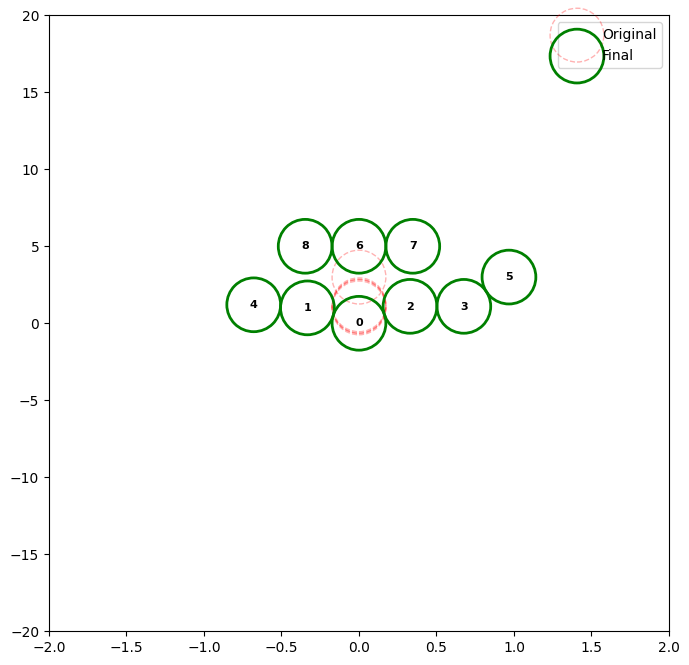

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

s = 1500

x = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
y = [0.0, 1.0, 1.1, 1.1, 1.2, 3.0, 5.0, 5.0, 5.0]


def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels


def check_overlap(pt1, pt2, s, fig, ax):
    """Check if two points overlap (returns True if they overlap)"""
    edge_dist = estimate_distance_data_units(pt1, pt2, s, fig, ax)
    return edge_dist < -1e-6  # Small tolerance for floating point errors


def calculate_shift_for_new_point(new_pt, existing_points, s, fig, ax, point_index):
    """
    Calculate the minimum horizontal shift needed for new_pt to:
    1. Not overlap with any existing point
    2. Be tangent to at least one existing point (only if currently overlapping)
    3. Move as little as possible
    """
    print(f"\n{'='*80}")
    print(f"PROCESSING POINT {point_index}: Original position {new_pt}")
    print(f"{'='*80}\n")
    
    # First, check if the current position is already valid (no overlaps)
    current_is_valid = True
    overlaps_with = []
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        if check_overlap(new_pt, existing_pt, s, fig, ax):
            current_is_valid = False
            overlaps_with.append(idx)
    
    if current_is_valid:
        print(f"✓ Current position is valid (no overlaps). No shift needed.\n")
        print(f"{'='*80}\n")
        return 0
    
    print(f"✗ Current position overlaps with points: {overlaps_with}")
    print(f"  Finding valid tangent positions...\n")
    
    # Convert new point to display coordinates
    new_pt_display = ax.transData.transform([new_pt])[0]
    
    # Calculate radius in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    target_distance_pixels = 2 * radius_pixels
    
    all_candidates = []
    valid_shifts = []
    
    # For each existing point, try to find tangent positions
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        existing_pt_display = ax.transData.transform([existing_pt])[0]
        
        # Calculate dy in display coordinates
        dy_pixels = abs(new_pt_display[1] - existing_pt_display[1])
        
        # Calculate required dx for tangency: sqrt((2*r)^2 - dy^2)
        dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
        
        if dx_pixels_squared < 0:
            # Points are too far apart vertically to be tangent with horizontal shift
            continue
        
        dx_pixels = np.sqrt(dx_pixels_squared)
        
        # Try both left and right of this existing point
        for sign, direction in [(1, "right"), (-1, "left")]:
            # Calculate where new point would be
            new_pt_candidate_display = np.array([
                existing_pt_display[0] + sign * dx_pixels, 
                new_pt_display[1]
            ])
            new_pt_candidate_data = ax.transData.inverted().transform([new_pt_candidate_display])[0]
            candidate_position = (new_pt_candidate_data[0], new_pt[1])
            shift_candidate = new_pt_candidate_data[0] - new_pt[0]
            
            # Check if this position overlaps with ANY OTHER existing point
            # (excluding the point we're tangent to, since we calculated this position to be tangent to it)
            is_valid = True
            overlaps_with_candidate = []
            for idx2, row2 in existing_points.iterrows():
                if idx2 == idx:
                    # Skip the point we're tangent to - by construction we should be tangent, not overlapping
                    continue
                    
                existing_pt2 = (row2['xnew'], row2['ynew'])
                if check_overlap(candidate_position, existing_pt2, s, fig, ax):
                    is_valid = False
                    overlaps_with_candidate.append(idx2)
            
            candidate_info = {
                'tangent_to_idx': idx,
                'direction': direction,
                'shift': shift_candidate,
                'abs_shift': abs(shift_candidate),
                'new_position': candidate_position,
                'is_valid': is_valid,
                'overlaps_with': overlaps_with_candidate
            }
            
            all_candidates.append(candidate_info)
            
            if is_valid:
                valid_shifts.append(candidate_info)
    
    # Print all candidates
    print(f"{'Tangent To':<12} {'Direction':<10} {'Shift':<12} {'|Shift|':<12} {'Valid':<8} {'Overlaps With'}")
    print(f"{'-'*80}")
    for c in all_candidates:
        valid_str = "✓ YES" if c['is_valid'] else "✗ NO"
        overlap_str = str(c['overlaps_with']) if c['overlaps_with'] else "-"
        print(f"Point {c['tangent_to_idx']:<6} {c['direction']:<10} {c['shift']:>10.4f}  {c['abs_shift']:>10.4f}  {valid_str:<8} {overlap_str}")
    
    if not valid_shifts:
        print("\n⚠ Warning: No valid tangent position found! Keeping original position.")
        return 0
    
    # Sort by absolute shift and pick the smallest
    valid_shifts.sort(key=lambda x: x['abs_shift'])
    best = valid_shifts[0]
    
    print(f"\n{'='*80}")
    print(f"✓ CHOSEN: Shift {best['direction']} of point {best['tangent_to_idx']}")
    print(f"  Shift amount: {best['shift']:.4f}")
    print(f"  Distance from original: {best['abs_shift']:.4f}")
    print(f"  New position: ({best['new_position'][0]:.4f}, {best['new_position'][1]:.4f})")
    print(f"{'='*80}\n")
    
    return best['shift']


def position_all_points(x, y, s, fig, ax):
    """
    Position all points iteratively:
    - Keep first point where it is
    - For each subsequent point, shift it to avoid overlaps with all previous points
    """
    n_points = len(x)
    
    # Initialize result dataframe
    result = pd.DataFrame({
        'point_index': range(n_points),
        'xorig': x,
        'yorig': y,
        'xnew': [None] * n_points,
        'ynew': [None] * n_points
    })
    
    # First point stays where it is
    result.loc[0, 'xnew'] = x[0]
    result.loc[0, 'ynew'] = y[0]
    print(f"\n{'='*80}")
    print(f"POINT 0: Keeping at original position ({x[0]:.4f}, {y[0]:.4f})")
    print(f"{'='*80}")
    
    # Process each subsequent point
    for i in range(1, n_points):
        current_pt = (x[i], y[i])
        
        # Get all previously positioned points
        positioned_so_far = result[result['xnew'].notna()].copy()
        
        # Calculate shift needed
        shift = calculate_shift_for_new_point(current_pt, positioned_so_far, s, fig, ax, i)
        
        # Apply shift
        result.loc[i, 'xnew'] = x[i] + shift
        result.loc[i, 'ynew'] = y[i]
    
    return result


# Run the positioning algorithm
final_positions = position_all_points(x, y, s, fig, ax)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(final_positions.to_string(index=False))

# Plot original positions (light, dashed)
ax.scatter(final_positions['xorig'], final_positions['yorig'], s=s, 
           edgecolors='red', facecolors='none', marker='o', 
           linewidths=1, linestyle='--', alpha=0.3, label='Original')

# Plot final positions (bold)
ax.scatter(final_positions['xnew'], final_positions['ynew'], s=s, 
           edgecolors='green', facecolors='none', marker='o', 
           linewidths=2, label='Final')

# Add point labels
for idx, row in final_positions.iterrows():
    ax.text(row['xnew'], row['ynew'], str(idx), 
            ha='center', va='center', fontsize=8, fontweight='bold')

ax.legend()
plt.show()


POINT 0: Keeping at original position (0.0000, 0.0000)

PROCESSING POINT 1: Original position (0.0, 1.0)

✗ Current position violates gap with points: [0]
  Finding valid positions with 5.0% gap...

  Radius: 31.06 pixels
  Gap: 3.11 pixels (5.0% of diameter)
  Target center-to-center distance: 65.22 pixels

Relative To   Direction  Shift        |Shift|      Valid    Violates Gap With
--------------------------------------------------------------------------------
Point 0       right          0.4089      0.4089  ✓ YES    -
Point 0       left          -0.4089      0.4089  ✓ YES    -

✓ CHOSEN: Shift right of point 0
  Shift amount: 0.4089
  Distance from original: 0.4089
  New position: (0.4089, 1.0000)


PROCESSING POINT 2: Original position (0.0, 1.1)

✗ Current position violates gap with points: [0, 1]
  Finding valid positions with 5.0% gap...

  Radius: 31.06 pixels
  Gap: 3.11 pixels (5.0% of diameter)
  Target center-to-center distance: 65.22 pixels

Relative To   Direction  Shi

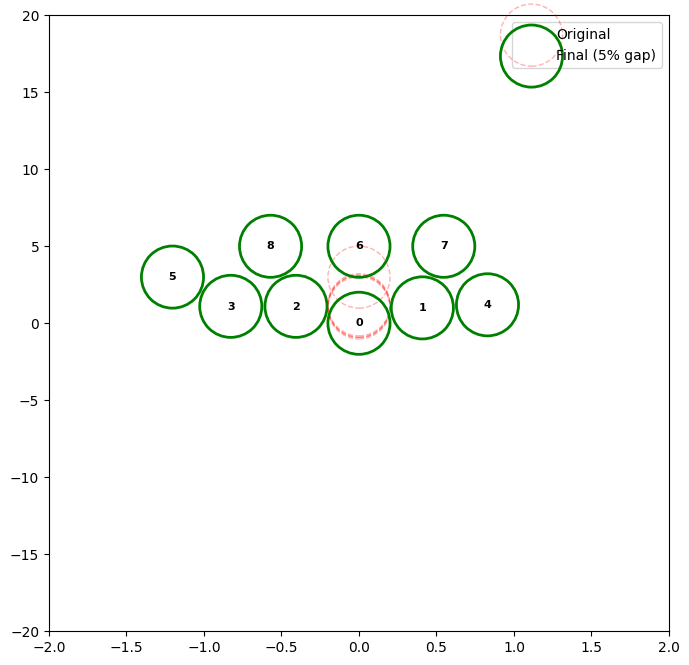

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

s = 2000
gap_fraction = 0.05  # 5% gap between circles

x = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
y = [0.0, 1.0, 1.1, 1.1, 1.2, 3.0, 5.0, 5.0, 5.0]


def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels


def check_overlap(pt1, pt2, s, gap_fraction, fig, ax):
    """
    Check if two points overlap or are too close (returns True if they violate the gap requirement)
    With gap_fraction, we require edge-to-edge distance >= gap_fraction * diameter
    """
    edge_dist_pixels = estimate_distance_data_units(pt1, pt2, s, fig, ax)
    
    # Calculate required gap in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    diameter_pixels = 2 * radius_pixels
    required_gap_pixels = gap_fraction * diameter_pixels
    
    # Return True if gap is violated (distance too small)
    return edge_dist_pixels < required_gap_pixels - 1e-6  # Small tolerance for floating point


def calculate_shift_for_new_point(new_pt, existing_points, s, gap_fraction, fig, ax, point_index):
    """
    Calculate the minimum horizontal shift needed for new_pt to:
    1. Maintain required gap with all existing points
    2. Be at the minimum valid distance from at least one existing point
    3. Move as little as possible
    """
    print(f"\n{'='*80}")
    print(f"PROCESSING POINT {point_index}: Original position {new_pt}")
    print(f"{'='*80}\n")
    
    # First, check if the current position is already valid (respects all gaps)
    current_is_valid = True
    violates_gap_with = []
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        if check_overlap(new_pt, existing_pt, s, gap_fraction, fig, ax):
            current_is_valid = False
            violates_gap_with.append(idx)
    
    if current_is_valid:
        print(f"✓ Current position is valid (all gaps satisfied). No shift needed.\n")
        print(f"{'='*80}\n")
        return 0
    
    print(f"✗ Current position violates gap with points: {violates_gap_with}")
    print(f"  Finding valid positions with {gap_fraction*100:.1f}% gap...\n")
    
    # Convert new point to display coordinates
    new_pt_display = ax.transData.transform([new_pt])[0]
    
    # Calculate radius in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Target distance between centers = 2*radius + gap
    # Gap should be gap_fraction * diameter = gap_fraction * 2 * radius
    gap_pixels = gap_fraction * 2 * radius_pixels
    target_distance_pixels = 2 * radius_pixels + gap_pixels
    
    print(f"  Radius: {radius_pixels:.2f} pixels")
    print(f"  Gap: {gap_pixels:.2f} pixels ({gap_fraction*100:.1f}% of diameter)")
    print(f"  Target center-to-center distance: {target_distance_pixels:.2f} pixels\n")
    
    all_candidates = []
    valid_shifts = []
    
    # For each existing point, try to find valid positions
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        existing_pt_display = ax.transData.transform([existing_pt])[0]
        
        # Calculate dy in display coordinates
        dy_pixels = abs(new_pt_display[1] - existing_pt_display[1])
        
        # Calculate required dx for target distance: sqrt(target_dist^2 - dy^2)
        dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
        
        if dx_pixels_squared < 0:
            # Points are too far apart vertically to achieve target distance with horizontal shift
            continue
        
        dx_pixels = np.sqrt(dx_pixels_squared)
        
        # Try both left and right of this existing point
        for sign, direction in [(1, "right"), (-1, "left")]:
            # Calculate where new point would be
            new_pt_candidate_display = np.array([
                existing_pt_display[0] + sign * dx_pixels, 
                new_pt_display[1]
            ])
            new_pt_candidate_data = ax.transData.inverted().transform([new_pt_candidate_display])[0]
            candidate_position = (new_pt_candidate_data[0], new_pt[1])
            shift_candidate = new_pt_candidate_data[0] - new_pt[0]
            
            # Check if this position violates gap with ANY OTHER existing point
            # (excluding the point we're positioned relative to)
            is_valid = True
            violates_gap_with_candidate = []
            for idx2, row2 in existing_points.iterrows():
                if idx2 == idx:
                    # Skip the point we're positioning relative to
                    continue
                    
                existing_pt2 = (row2['xnew'], row2['ynew'])
                if check_overlap(candidate_position, existing_pt2, s, gap_fraction, fig, ax):
                    is_valid = False
                    violates_gap_with_candidate.append(idx2)
            
            candidate_info = {
                'relative_to_idx': idx,
                'direction': direction,
                'shift': shift_candidate,
                'abs_shift': abs(shift_candidate),
                'new_position': candidate_position,
                'is_valid': is_valid,
                'violates_gap_with': violates_gap_with_candidate
            }
            
            all_candidates.append(candidate_info)
            
            if is_valid:
                valid_shifts.append(candidate_info)
    
    # Print all candidates
    print(f"{'Relative To':<13} {'Direction':<10} {'Shift':<12} {'|Shift|':<12} {'Valid':<8} {'Violates Gap With'}")
    print(f"{'-'*80}")
    for c in all_candidates:
        valid_str = "✓ YES" if c['is_valid'] else "✗ NO"
        violates_str = str(c['violates_gap_with']) if c['violates_gap_with'] else "-"
        print(f"Point {c['relative_to_idx']:<7} {c['direction']:<10} {c['shift']:>10.4f}  {c['abs_shift']:>10.4f}  {valid_str:<8} {violates_str}")
    
    if not valid_shifts:
        print("\n⚠ Warning: No valid position found! Keeping original position.")
        return 0
    
    # Sort by absolute shift and pick the smallest
    valid_shifts.sort(key=lambda x: x['abs_shift'])
    best = valid_shifts[0]
    
    print(f"\n{'='*80}")
    print(f"✓ CHOSEN: Shift {best['direction']} of point {best['relative_to_idx']}")
    print(f"  Shift amount: {best['shift']:.4f}")
    print(f"  Distance from original: {best['abs_shift']:.4f}")
    print(f"  New position: ({best['new_position'][0]:.4f}, {best['new_position'][1]:.4f})")
    print(f"{'='*80}\n")
    
    return best['shift']


def position_all_points(x, y, s, gap_fraction, fig, ax):
    """
    Position all points iteratively:
    - Keep first point where it is
    - For each subsequent point, shift it to maintain required gaps with all previous points
    """
    n_points = len(x)
    
    # Initialize result dataframe
    result = pd.DataFrame({
        'point_index': range(n_points),
        'xorig': x,
        'yorig': y,
        'xnew': [None] * n_points,
        'ynew': [None] * n_points
    })
    
    # First point stays where it is
    result.loc[0, 'xnew'] = x[0]
    result.loc[0, 'ynew'] = y[0]
    print(f"\n{'='*80}")
    print(f"POINT 0: Keeping at original position ({x[0]:.4f}, {y[0]:.4f})")
    print(f"{'='*80}")
    
    # Process each subsequent point
    for i in range(1, n_points):
        current_pt = (x[i], y[i])
        
        # Get all previously positioned points
        positioned_so_far = result[result['xnew'].notna()].copy()
        
        # Calculate shift needed
        shift = calculate_shift_for_new_point(current_pt, positioned_so_far, s, gap_fraction, fig, ax, i)
        
        # Apply shift
        result.loc[i, 'xnew'] = x[i] + shift
        result.loc[i, 'ynew'] = y[i]
    
    return result


# Run the positioning algorithm
final_positions = position_all_points(x, y, s, gap_fraction, fig, ax)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(final_positions.to_string(index=False))

# Plot original positions (light, dashed)
ax.scatter(final_positions['xorig'], final_positions['yorig'], s=s, 
           edgecolors='red', facecolors='none', marker='o', 
           linewidths=1, linestyle='--', alpha=0.3, label='Original')

# Plot final positions (bold)
ax.scatter(final_positions['xnew'], final_positions['ynew'], s=s, 
           edgecolors='green', facecolors='none', marker='o', 
           linewidths=2, label=f'Final ({gap_fraction*100:.0f}% gap)')

# Add point labels
for idx, row in final_positions.iterrows():
    ax.text(row['xnew'], row['ynew'], str(idx), 
            ha='center', va='center', fontsize=8, fontweight='bold')

ax.legend()
plt.show()


PROCESSING ORDER (sorted by y-coordinate):
 original_index  xorig  yorig  processing_order
              0    0.0    0.0                 0
              1    0.0    1.0                 1
              2    0.0    1.1                 2
              3    0.0    1.1                 3
              4    0.0    1.2                 4
              9    1.0    2.0                 5
             10    1.0    2.4                 6
             11    1.0    2.6                 7
             12    1.0    2.8                 8
             13    1.0    2.8                 9
              5    0.0    3.0                10
             14    1.0    3.0                11
             15    1.0    3.1                12
             16    1.0    3.2                13
             17    1.0    3.4                14
              6    0.0    5.0                15
              7    0.0    5.0                16
              8    0.0    5.0                17

POINT 0 (processing order 0): Keeping at or

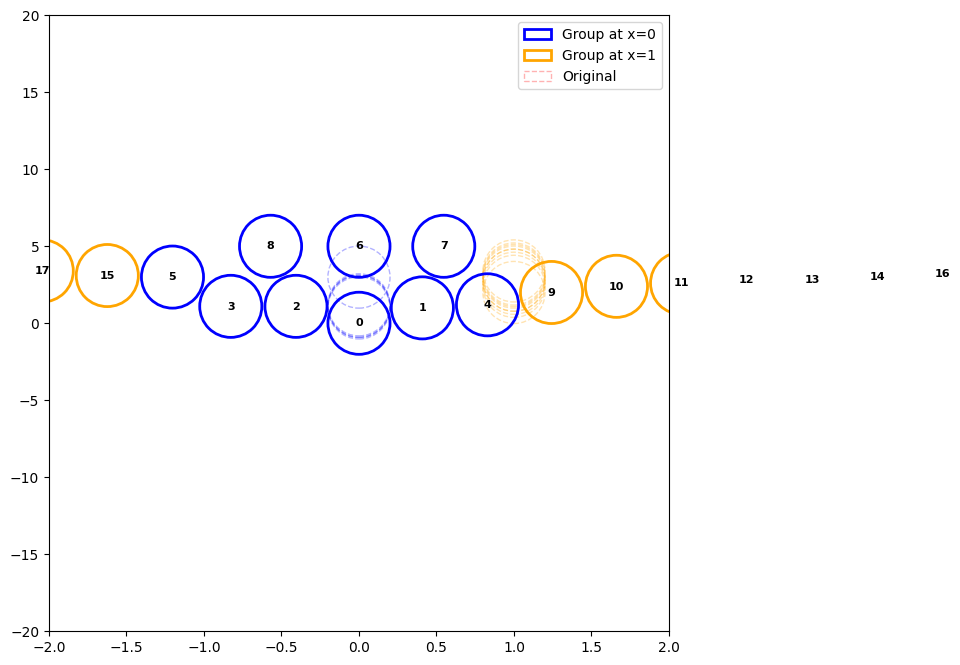

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)

s = 2000
gap_fraction = 0.05  # 5% gap between circles

x = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
y = [0.0, 1.0, 1.1, 1.1, 1.2, 3.0, 5.0, 5.0, 5.0, 2.0, 2.4, 2.6, 2.8, 2.8, 3.0, 3.1, 3.2, 3.4]


def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels


def check_overlap(pt1, pt2, s, gap_fraction, fig, ax):
    """
    Check if two points overlap or are too close (returns True if they violate the gap requirement)
    With gap_fraction, we require edge-to-edge distance >= gap_fraction * diameter
    """
    edge_dist_pixels = estimate_distance_data_units(pt1, pt2, s, fig, ax)
    
    # Calculate required gap in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    diameter_pixels = 2 * radius_pixels
    required_gap_pixels = gap_fraction * diameter_pixels
    
    # Return True if gap is violated (distance too small)
    return edge_dist_pixels < required_gap_pixels - 1e-6  # Small tolerance for floating point


def calculate_shift_for_new_point(new_pt, existing_points, s, gap_fraction, fig, ax, point_index):
    """
    Calculate the minimum horizontal shift needed for new_pt to:
    1. Maintain required gap with all existing points
    2. Be at the minimum valid distance from at least one existing point
    3. Move as little as possible
    """
    print(f"\n{'='*80}")
    print(f"PROCESSING POINT {point_index}: Original position {new_pt}")
    print(f"{'='*80}\n")
    
    # First, check if the current position is already valid (respects all gaps)
    current_is_valid = True
    violates_gap_with = []
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        if check_overlap(new_pt, existing_pt, s, gap_fraction, fig, ax):
            current_is_valid = False
            violates_gap_with.append(idx)
    
    if current_is_valid:
        print(f"✓ Current position is valid (all gaps satisfied). No shift needed.\n")
        print(f"{'='*80}\n")
        return 0
    
    print(f"✗ Current position violates gap with points: {violates_gap_with}")
    print(f"  Finding valid positions with {gap_fraction*100:.1f}% gap...\n")
    
    # Convert new point to display coordinates
    new_pt_display = ax.transData.transform([new_pt])[0]
    
    # Calculate radius in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Target distance between centers = 2*radius + gap
    # Gap should be gap_fraction * diameter = gap_fraction * 2 * radius
    gap_pixels = gap_fraction * 2 * radius_pixels
    target_distance_pixels = 2 * radius_pixels + gap_pixels
    
    all_candidates = []
    valid_shifts = []
    
    # For each existing point, try to find valid positions
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        existing_pt_display = ax.transData.transform([existing_pt])[0]
        
        # Calculate dy in display coordinates
        dy_pixels = abs(new_pt_display[1] - existing_pt_display[1])
        
        # Calculate required dx for target distance: sqrt(target_dist^2 - dy^2)
        dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
        
        if dx_pixels_squared < 0:
            # Points are too far apart vertically to achieve target distance with horizontal shift
            continue
        
        dx_pixels = np.sqrt(dx_pixels_squared)
        
        # Try both left and right of this existing point
        for sign, direction in [(1, "right"), (-1, "left")]:
            # Calculate where new point would be
            new_pt_candidate_display = np.array([
                existing_pt_display[0] + sign * dx_pixels, 
                new_pt_display[1]
            ])
            new_pt_candidate_data = ax.transData.inverted().transform([new_pt_candidate_display])[0]
            candidate_position = (new_pt_candidate_data[0], new_pt[1])
            shift_candidate = new_pt_candidate_data[0] - new_pt[0]
            
            # Check if this position violates gap with ANY OTHER existing point
            # (excluding the point we're positioned relative to)
            is_valid = True
            violates_gap_with_candidate = []
            for idx2, row2 in existing_points.iterrows():
                if idx2 == idx:
                    # Skip the point we're positioning relative to
                    continue
                    
                existing_pt2 = (row2['xnew'], row2['ynew'])
                if check_overlap(candidate_position, existing_pt2, s, gap_fraction, fig, ax):
                    is_valid = False
                    violates_gap_with_candidate.append(idx2)
            
            candidate_info = {
                'relative_to_idx': idx,
                'direction': direction,
                'shift': shift_candidate,
                'abs_shift': abs(shift_candidate),
                'new_position': candidate_position,
                'is_valid': is_valid,
                'violates_gap_with': violates_gap_with_candidate
            }
            
            all_candidates.append(candidate_info)
            
            if is_valid:
                valid_shifts.append(candidate_info)
    
    # Print all candidates
    print(f"{'Relative To':<13} {'Direction':<10} {'Shift':<12} {'|Shift|':<12} {'Valid':<8} {'Violates Gap With'}")
    print(f"{'-'*80}")
    for c in all_candidates:
        valid_str = "✓ YES" if c['is_valid'] else "✗ NO"
        violates_str = str(c['violates_gap_with']) if c['violates_gap_with'] else "-"
        print(f"Point {c['relative_to_idx']:<7} {c['direction']:<10} {c['shift']:>10.4f}  {c['abs_shift']:>10.4f}  {valid_str:<8} {violates_str}")
    
    if not valid_shifts:
        print("\n⚠ Warning: No valid position found! Keeping original position.")
        return 0
    
    # Sort by absolute shift and pick the smallest
    valid_shifts.sort(key=lambda x: x['abs_shift'])
    best = valid_shifts[0]
    
    print(f"\n{'='*80}")
    print(f"✓ CHOSEN: Shift {best['direction']} of point {best['relative_to_idx']}")
    print(f"  Shift amount: {best['shift']:.4f}")
    print(f"  Distance from original: {best['abs_shift']:.4f}")
    print(f"  New position: ({best['new_position'][0]:.4f}, {best['new_position'][1]:.4f})")
    print(f"{'='*80}\n")
    
    return best['shift']


def position_all_points(x, y, s, gap_fraction, fig, ax):
    """
    Position all points iteratively, processing them in order of y-coordinate:
    - Sort all points by y-coordinate
    - Keep first point (lowest y) where it is
    - For each subsequent point, shift it to maintain required gaps with all previous points
    """
    n_points = len(x)
    
    # Create dataframe with original order and positions
    data = pd.DataFrame({
        'original_index': range(n_points),
        'xorig': x,
        'yorig': y,
        'xnew': [None] * n_points,
        'ynew': [None] * n_points
    })
    
    # Sort by y-coordinate (and by x as tiebreaker for stability)
    data = data.sort_values(['yorig', 'xorig']).reset_index(drop=True)
    data['processing_order'] = range(n_points)
    
    print(f"\n{'='*80}")
    print(f"PROCESSING ORDER (sorted by y-coordinate):")
    print(f"{'='*80}")
    print(data[['original_index', 'xorig', 'yorig', 'processing_order']].to_string(index=False))
    
    # First point stays where it is
    data.loc[0, 'xnew'] = data.loc[0, 'xorig']
    data.loc[0, 'ynew'] = data.loc[0, 'yorig']
    print(f"\n{'='*80}")
    print(f"POINT {data.loc[0, 'original_index']} (processing order 0): Keeping at original position ({data.loc[0, 'xorig']:.4f}, {data.loc[0, 'yorig']:.4f})")
    print(f"{'='*80}")
    
    # Process each subsequent point
    for i in range(1, n_points):
        current_pt = (data.loc[i, 'xorig'], data.loc[i, 'yorig'])
        original_idx = data.loc[i, 'original_index']
        
        # Get all previously positioned points
        positioned_so_far = data[data['xnew'].notna()].copy()
        
        # Calculate shift needed
        shift = calculate_shift_for_new_point(current_pt, positioned_so_far, s, gap_fraction, fig, ax, original_idx)
        
        # Apply shift
        data.loc[i, 'xnew'] = data.loc[i, 'xorig'] + shift
        data.loc[i, 'ynew'] = data.loc[i, 'yorig']
    
    # Sort back to original order for output
    result = data.sort_values('original_index').reset_index(drop=True)
    
    return result


# Run the positioning algorithm
final_positions = position_all_points(x, y, s, gap_fraction, fig, ax)

print("\n" + "="*80)
print("FINAL RESULTS (original order)")
print("="*80)
print(final_positions[['original_index', 'xorig', 'yorig', 'xnew', 'ynew']].to_string(index=False))

# Identify groups by original x-coordinate
colors = ['blue' if x_val < 0.5 else 'orange' for x_val in final_positions['xorig']]

# Plot original positions (light, dashed)
for i, row in final_positions.iterrows():
    ax.scatter([row['xorig']], [row['yorig']], s=s, 
               edgecolors=colors[i], facecolors='none', marker='o', 
               linewidths=1, linestyle='--', alpha=0.3)

# Plot final positions (bold)
for i, row in final_positions.iterrows():
    ax.scatter([row['xnew']], [row['ynew']], s=s, 
               edgecolors=colors[i], facecolors='none', marker='o', 
               linewidths=2)
    ax.text(row['xnew'], row['ynew'], str(row['original_index']), 
            ha='center', va='center', fontsize=8, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor='blue', linewidth=2, label='Group at x=0'),
    Patch(facecolor='none', edgecolor='orange', linewidth=2, label='Group at x=1'),
    Patch(facecolor='none', edgecolor='red', linewidth=1, linestyle='--', alpha=0.3, label='Original'),
]
ax.legend(handles=legend_elements)

plt.show()

In [9]:
def estimate_distance_data_units(p1, p2, s, fig, ax):
    # Calculate the distance from the edge of one point to the edge of the other in display units
    
    # Convert points to display coordinates
    p1_display = ax.transData.transform([p1])[0]
    p2_display = ax.transData.transform([p2])[0]
    
    # Calculate distance between centers in pixels
    distance_pixels = np.sqrt((p2_display[0] - p1_display[0])**2 + 
                              (p2_display[1] - p1_display[1])**2)
    
    # Calculate radius in pixels from s
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Distance from edge to edge = distance between centers - 2*radius
    edge_to_edge_pixels = distance_pixels - 2 * radius_pixels
    
    return edge_to_edge_pixels


def check_overlap(pt1, pt2, s, gap_fraction, fig, ax):
    """
    Check if two points overlap or are too close (returns True if they violate the gap requirement)
    With gap_fraction, we require edge-to-edge distance >= gap_fraction * diameter
    """
    edge_dist_pixels = estimate_distance_data_units(pt1, pt2, s, fig, ax)
    
    # Calculate required gap in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    diameter_pixels = 2 * radius_pixels
    required_gap_pixels = gap_fraction * diameter_pixels
    
    # Return True if gap is violated (distance too small)
    return edge_dist_pixels < required_gap_pixels - 1e-6  # Small tolerance for floating point


def calculate_shift_for_new_point(new_pt, existing_points, s, gap_fraction, fig, ax, point_index, verbose_inner=True):
    """
    Calculate the minimum horizontal shift needed for new_pt to:
    1. Maintain required gap with all existing points
    2. Be at the minimum valid distance from at least one existing point
    3. Move as little as possible
    """
    if verbose_inner:
        print(f"\n{'='*80}")
        print(f"PROCESSING POINT {point_index}: Original position {new_pt}")
        print(f"{'='*80}\n")
    
    # First, check if the current position is already valid (respects all gaps)
    current_is_valid = True
    violates_gap_with = []
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        if check_overlap(new_pt, existing_pt, s, gap_fraction, fig, ax):
            current_is_valid = False
            violates_gap_with.append(idx)
    
    if current_is_valid:
        if verbose_inner:
            print(f"✓ Current position is valid (all gaps satisfied). No shift needed.\n")
            print(f"{'='*80}\n")
        return 0
    
    if verbose_inner:
        print(f"✗ Current position violates gap with points: {violates_gap_with}")
        print(f"  Finding valid positions with {gap_fraction*100:.1f}% gap...\n")
    
    # Convert new point to display coordinates
    new_pt_display = ax.transData.transform([new_pt])[0]
    
    # Calculate radius in pixels
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    
    # Target distance between centers = 2*radius + gap
    # Gap should be gap_fraction * diameter = gap_fraction * 2 * radius
    gap_pixels = gap_fraction * 2 * radius_pixels
    target_distance_pixels = 2 * radius_pixels + gap_pixels
    
    all_candidates = []
    valid_shifts = []
    
    # For each existing point, try to find valid positions
    for idx, row in existing_points.iterrows():
        existing_pt = (row['xnew'], row['ynew'])
        existing_pt_display = ax.transData.transform([existing_pt])[0]
        
        # Calculate dy in display coordinates
        dy_pixels = abs(new_pt_display[1] - existing_pt_display[1])
        
        # Calculate required dx for target distance: sqrt(target_dist^2 - dy^2)
        dx_pixels_squared = target_distance_pixels**2 - dy_pixels**2
        
        if dx_pixels_squared < 0:
            # Points are too far apart vertically to achieve target distance with horizontal shift
            continue
        
        dx_pixels = np.sqrt(dx_pixels_squared)
        
        # Try both left and right of this existing point
        for sign, direction in [(1, "right"), (-1, "left")]:
            # Calculate where new point would be
            new_pt_candidate_display = np.array([
                existing_pt_display[0] + sign * dx_pixels, 
                new_pt_display[1]
            ])
            new_pt_candidate_data = ax.transData.inverted().transform([new_pt_candidate_display])[0]
            candidate_position = (new_pt_candidate_data[0], new_pt[1])
            shift_candidate = new_pt_candidate_data[0] - new_pt[0]
            
            # Check if this position violates gap with ANY OTHER existing point
            # (excluding the point we're positioned relative to)
            is_valid = True
            violates_gap_with_candidate = []
            for idx2, row2 in existing_points.iterrows():
                if idx2 == idx:
                    # Skip the point we're positioning relative to
                    continue
                    
                existing_pt2 = (row2['xnew'], row2['ynew'])
                if check_overlap(candidate_position, existing_pt2, s, gap_fraction, fig, ax):
                    is_valid = False
                    violates_gap_with_candidate.append(idx2)
            
            candidate_info = {
                'relative_to_idx': idx,
                'direction': direction,
                'shift': shift_candidate,
                'abs_shift': abs(shift_candidate),
                'new_position': candidate_position,
                'is_valid': is_valid,
                'violates_gap_with': violates_gap_with_candidate
            }
            
            all_candidates.append(candidate_info)
            
            if is_valid:
                valid_shifts.append(candidate_info)
    
    if verbose_inner and all_candidates:
        # Print all candidates
        print(f"{'Relative To':<13} {'Direction':<10} {'Shift':<12} {'|Shift|':<12} {'Valid':<8} {'Violates Gap With'}")
        print(f"{'-'*80}")
        for c in all_candidates:
            valid_str = "✓ YES" if c['is_valid'] else "✗ NO"
            violates_str = str(c['violates_gap_with']) if c['violates_gap_with'] else "-"
            print(f"Point {c['relative_to_idx']:<7} {c['direction']:<10} {c['shift']:>10.4f}  {c['abs_shift']:>10.4f}  {valid_str:<8} {violates_str}")
    
    if not valid_shifts:
        if verbose_inner:
            print("\n⚠ Warning: No valid position found! Keeping original position.")
        return None  # Return None to indicate failure
    
    # Sort by absolute shift and pick the smallest
    valid_shifts.sort(key=lambda x: x['abs_shift'])
    best = valid_shifts[0]
    
    if verbose_inner:
        print(f"\n{'='*80}")
        print(f"✓ CHOSEN: Shift {best['direction']} of point {best['relative_to_idx']}")
        print(f"  Shift amount: {best['shift']:.4f}")
        print(f"  Distance from original: {best['abs_shift']:.4f}")
        print(f"  New position: ({best['new_position'][0]:.4f}, {best['new_position'][1]:.4f})")
        print(f"{'='*80}\n")
    
    return best['shift']


def position_all_points(x, y, s, gap_fraction, fig, ax, verbose_inner=True):
    """
    Position all points iteratively, processing them in order of y-coordinate:
    - Sort all points by y-coordinate
    - Keep first point (lowest y) where it is
    - For each subsequent point, shift it to maintain required gaps with all previous points
    
    Returns: result dataframe, max_shift_and_radius
    """
    n_points = len(x)
    
    # Create dataframe with original order and positions
    data = pd.DataFrame({
        'original_index': range(n_points),
        'xorig': x,
        'yorig': y,
        'xnew': [None] * n_points,
        'ynew': [None] * n_points,
        'shift': [None] * n_points
    })
    
    # Sort by y-coordinate (and by x as tiebreaker for stability)
    data = data.sort_values(['yorig', 'xorig']).reset_index(drop=True)
    data['processing_order'] = range(n_points)
    
    if verbose_inner:
        print(f"\n{'='*80}")
        print(f"PROCESSING ORDER (sorted by y-coordinate):")
        print(f"{'='*80}")
        print(data[['original_index', 'xorig', 'yorig', 'processing_order']].to_string(index=False))
    
    # First point stays where it is
    data.loc[0, 'xnew'] = data.loc[0, 'xorig']
    data.loc[0, 'ynew'] = data.loc[0, 'yorig']
    data.loc[0, 'shift'] = 0.0
    if verbose_inner:
        print(f"\n{'='*80}")
        print(f"POINT {data.loc[0, 'original_index']} (processing order 0): Keeping at original position ({data.loc[0, 'xorig']:.4f}, {data.loc[0, 'yorig']:.4f})")
        print(f"{'='*80}")
    
    # Process each subsequent point
    max_shift = 0.0
    for i in range(1, n_points):
        current_pt = (data.loc[i, 'xorig'], data.loc[i, 'yorig'])
        original_idx = data.loc[i, 'original_index']
        
        # Get all previously positioned points
        positioned_so_far = data[data['xnew'].notna()].copy()
        
        # Calculate shift needed
        shift = calculate_shift_for_new_point(current_pt, positioned_so_far, s, gap_fraction, fig, ax, original_idx, verbose_inner)
        
        if shift is None:
            # No valid position found - this s is too large
            return None, None
        
        # Apply shift
        data.loc[i, 'xnew'] = data.loc[i, 'xorig'] + shift
        data.loc[i, 'ynew'] = data.loc[i, 'yorig']
        data.loc[i, 'shift'] = shift
        max_shift = max(max_shift, abs(shift))
    
    # Calculate radius in data units
    radius_points = np.sqrt(s) / 2
    radius_pixels = radius_points * (fig.dpi / 72)
    # Convert radius to data units
    origin_display = ax.transData.transform([(0, 0)])[0]
    radius_offset_display = origin_display + np.array([radius_pixels, 0])
    radius_data = ax.transData.inverted().transform([radius_offset_display])[0]
    radius_in_data_units = abs(radius_data[0])
    
    # Maximum extent from original position
    max_shift_and_radius = max_shift + radius_in_data_units
    
    # Sort back to original order for output
    result = data.sort_values('original_index').reset_index(drop=True)
    
    return result, max_shift_and_radius


def find_optimal_s(x, y, gap_fraction, margin, fig, ax, tol = 1e-4, N_seq = 5, tol_seq = 1e-4, max_iterations=50, verbose_optim_min = True,
                   verbose_optim_full=True, verbose_inner=False):
    """
    Find the largest s such that all points can be positioned within margin of their original x-coordinate.
    Margin constraint: |shift| + radius <= margin for all points
    """
    if verbose_optim_full:
        print(f"\n{'#'*80}")
        print(f"# FINDING OPTIMAL s WITH MARGIN = {margin}")
        print(f"{'#'*80}\n")
    
    # Binary search for optimal s
    s_min = 100  # Minimum reasonable size
    s_max = 10000  # Maximum size to try
    
    best_s = None
    best_result = None

    # history of tests
    history = []
    
    seq_errors = []
    best_error = None
    max_seq_error = float('inf')
    iteration = 0
    while True:
        iteration += 1
        s_test = (s_min + s_max) / 2

        if verbose_optim_full:
            print(f"\n{'='*80}")
            print(f"ITERATION {iteration}: Testing s = {s_test:.1f} (range: [{s_min:.1f}, {s_max:.1f}])")
            print(f"{'='*80}")
            
        if verbose_optim_min:
            print(f"Iteration {iteration}: Testing s = {s_test:.1f}.")

        # Try positioning with this s
        result, max_shift_and_radius = position_all_points(x, y, s_test, gap_fraction, fig, ax, verbose_inner=verbose_inner)
        
        # derive max_shift if result provides per-point shifts
        max_shift = None
        if result is not None and 'shift' in result.columns:
            try:
                max_shift = float(result['shift'].abs().max())
            except Exception:
                max_shift = None

        if result is None:
            valid = False
            # Failed to position - s is too large
            if verbose_optim_min:
                print(f"   Result: ❌ FAILED: Could not position all points (s too large)")
            s_max = s_test
        elif max_shift_and_radius > margin:
            # Positioned but exceeds margin - s is too large
            valid = False
            if verbose_optim_min:
                print(f"   Iteration {iteration}: Testing s = {s_test:.1f}. Result: ❌ FAILED: Max shift+radius = {max_shift_and_radius:.4f} > margin {margin:.4f}")
            s_max = s_test
        else:
            valid = True
            # Success! Try larger s
            if verbose_optim_min:
                print(f"   Iteration {iteration}: Testing s = {s_test:.1f}. Result: ✅ SUCCESS: Max shift+radius = {max_shift_and_radius:.4f} <= margin {margin:.4f}")
                print(f"   Current best error: {best_error}.")
            best_s = s_test
            best_result = result
            s_min = s_test
    
        error = abs(margin - max_shift_and_radius)
        if best_error is None or (error < best_error and valid):
            best_error = error
            seq_errors.append(error)
            if len(seq_errors) > N_seq:
                seq_errors = seq_errors[-N_seq:]
                seq_error_diff = [val - seq_errors[-1] for val in seq_errors[:-1]]
                max_seq_error = np.max(np.abs(seq_error_diff))


        # record test outcome
        history.append({
            'iteration': iteration,
            's_test': s_test,
            'error': error,
            'max_seq_error': max_seq_error,
            'valid': valid,
            'max_shift_and_radius': max_shift_and_radius,
            'max_shift': max_shift
        })
        # Stopping conditions
        if iteration >= max_iterations:
            break
        if error < tol and valid:
            break
        if max_seq_error < tol_seq and iteration > 15:
            break
        
    if verbose_optim_full:
        print(f'Tolerance check: error={error}, tol={tol}, valid={valid}, iterations={iteration}')
        print(f'Is iterations >= max_iterations? {iteration >= max_iterations}')
        print(f'Is error < tol? {error < tol}')
        print(f'Is the result valid? {valid}')
        print(f'Is max_seq_error < tol_seq? {max_seq_error < tol_seq} (max_seq_error={max_seq_error}, tol_seq={tol_seq})')
        if max_seq_error < tol_seq and iteration > 15:
            print(f'Seq error values (last {N_seq}): {seq_errors}')
            print(f'Seq error diffs: {[val - seq_errors[-1] for val in seq_errors[:-1]]}')
            print(f'Max seq error: {max_seq_error}')

    if best_s is None:
        print(f"\n⚠️  WARNING: Could not find valid s within range. Using minimum s = {s_min:.1f}")
        best_s = s_min
        best_result, _ = position_all_points(x, y, best_s, gap_fraction, fig, ax, verbose_inner=verbose_inner)
    
    if verbose_optim_full:
        print(f"\n{'#'*80}")
        print(f"# OPTIMAL s FOUND: {best_s:.1f}")
        print(f"{'#'*80}\n")
        
        # Run one more time with verbose output
        print(f"\n{'='*80}")
        print(f"FINAL POSITIONING WITH s = {best_s:.1f}")
        print(f"{'='*80}")
    final_result, max_extent = position_all_points(x, y, best_s, gap_fraction, fig, ax, verbose_inner=verbose_inner)

    # attach history to the function for later inspection and print compact summary
    find_optimal_s.history = history
    if verbose_optim_full:
        print("\nTest history (s_test, success, max_shift_and_radius, max_shift):")
        for h in history:
            print(f"  {h['s_test']:10.1f}  {str(h['success']):5}  {str(h['max_shift_and_radius']):>10}  {str(h['max_shift']):>8}")
    
    return best_s, final_result, max_extent, history



Iteration 1: Testing s = 5050.0.
   Iteration 1: Testing s = 5050.0. Result: ❌ FAILED: Max shift+radius = 0.9735 > margin 0.4000
Iteration 2: Testing s = 2575.0.
   Iteration 2: Testing s = 2575.0. Result: ❌ FAILED: Max shift+radius = 0.4588 > margin 0.4000
Iteration 3: Testing s = 1337.5.
   Iteration 3: Testing s = 1337.5. Result: ✅ SUCCESS: Max shift+radius = 0.3691 <= margin 0.4000
   Current best error: 0.573535861207458.
Iteration 4: Testing s = 1956.2.
   Iteration 4: Testing s = 1956.2. Result: ✅ SUCCESS: Max shift+radius = 0.3840 <= margin 0.4000
   Current best error: 0.03094135953210342.
Iteration 5: Testing s = 2265.6.
   Iteration 5: Testing s = 2265.6. Result: ❌ FAILED: Max shift+radius = 0.4141 > margin 0.4000
Iteration 6: Testing s = 2110.9.
   Iteration 6: Testing s = 2110.9. Result: ✅ SUCCESS: Max shift+radius = 0.3883 <= margin 0.4000
   Current best error: 0.01596249330676669.
Iteration 7: Testing s = 2188.3.
   Iteration 7: Testing s = 2188.3. Result: ❌ FAILED: Max

/tmp/ipykernel_3232723/2084998380.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")  # You can choose a different colormap if desired


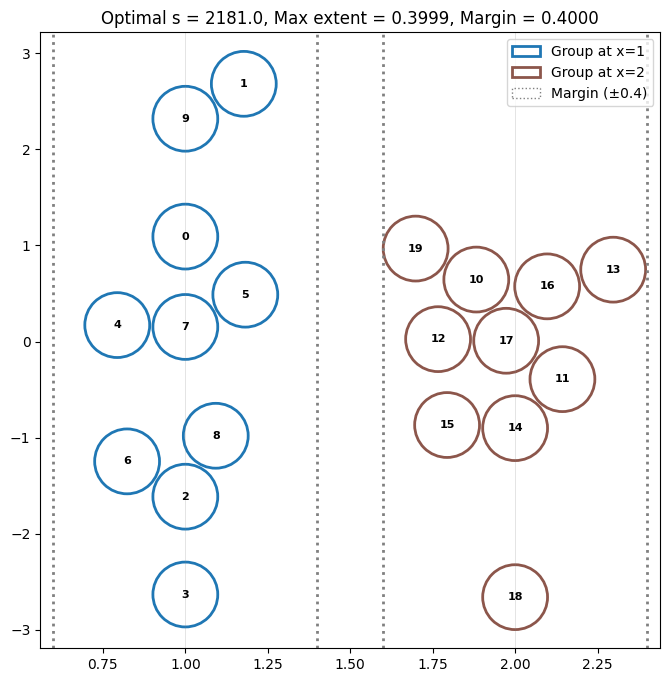

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex

# Generate data
d1 = np.random.uniform(low=-3, high=3, size=10)
d2 = np.random.normal(size=10)
data = {}
data['x'] = np.concatenate([np.repeat(1, len(d1)), np.repeat(2, len(d2))])
data['y'] = np.concatenate([d1, d2])

labels = ["sample 1", "sample 2"]

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_ylim(1.2 * min(data['y']), 1.2 * max(data['y']))

gap_fraction = 0.05  # 5% gap between circles
margin = 0.4  # Maximum distance from original x position (including circle radius)

x = data['x']
y = data['y']

ax.set_xlim(-1.1 * margin + min(x), 1.1 * margin + max(x))

# Find optimal s
optimal_s, final_positions, max_extent, history = find_optimal_s(
    x, y, gap_fraction, margin, fig, ax, 
    tol=1e-4, max_iterations=50, verbose_optim_min=True, verbose_optim_full=False, verbose_inner=False
)

# Get unique x positions to draw margin lines
unique_x = sorted(set(x))

# Draw margin lines for each unique x position
for x_pos in unique_x:
    ax.axvline(x=x_pos - margin, color='gray', linestyle=':', linewidth=2)
    ax.axvline(x=x_pos + margin, color='gray', linestyle=':', linewidth=2)
    ax.axvline(x=x_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# Use a colormap to assign colors based on unique x values
cmap = get_cmap("tab10")  # You can choose a different colormap if desired
x_to_color = {val: to_hex(cmap(i / len(unique_x))) for i, val in enumerate(unique_x)}

# Plot final positions (bold) with dynamic colors
for i, row in final_positions.iterrows():
    color = x_to_color[row['xorig']]
    ax.scatter([row['xnew']], [row['ynew']], s=optimal_s, 
               edgecolors=color, facecolors='none', marker='o', 
               linewidths=2)
    ax.text(row['xnew'], row['ynew'], str(row['original_index']), 
            ha='center', va='center', fontsize=8, fontweight='bold')

# Add legend dynamically based on unique x values
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor=color, linewidth=2, label=f'Group at x={x_val}')
    for x_val, color in x_to_color.items()
]
legend_elements.append(Patch(facecolor='none', edgecolor='gray', linestyle=':', linewidth=1, label=f'Margin (±{margin})'))
ax.legend(handles=legend_elements)

plt.title(f"Optimal s = {optimal_s:.1f}, Max extent = {max_extent:.4f}, Margin = {margin:.4f}")
plt.show()

In [13]:
data

{'y': array([-0.57787218, -0.71608507, -1.15168944, -2.40521287,  1.31611324,
         2.93088572, -2.02399914,  1.97126031, -2.3365174 , -1.92868437,
        -0.07041782, -0.04055602,  0.51931946, -0.03761608,  0.59921322,
        -1.11420101,  1.16000544, -2.13688896,  1.2888894 ,  0.84890456]),
 'x': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])}

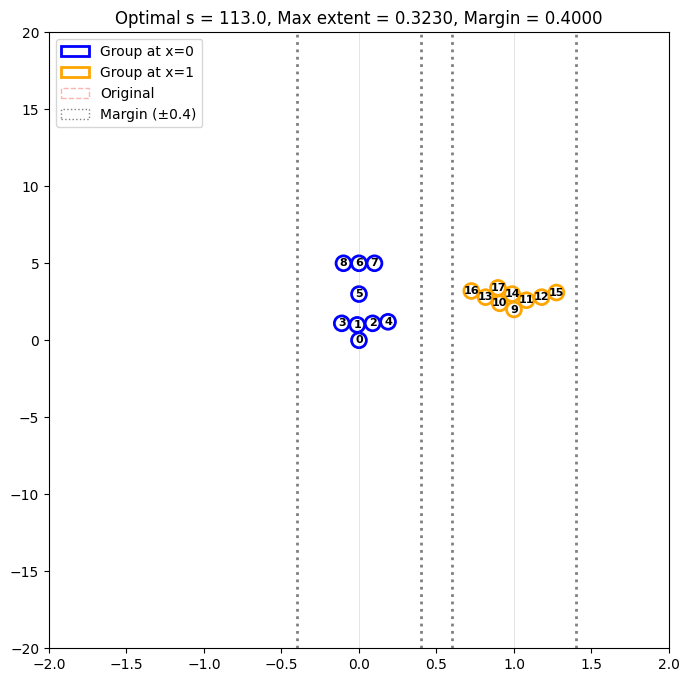

In [120]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 2)
ax.set_ylim(-20, 20)



final_positions, max_extent = position_all_points(x, y, 113.0, gap_fraction, fig, ax, verbose_inner=False)
# Get unique x positions to draw margin lines
unique_x = sorted(set(x))

# Draw margin lines for each unique x position
for x_pos in unique_x:
    ax.axvline(x=x_pos - margin, color='gray', linestyle=':', linewidth=2)
    ax.axvline(x=x_pos + margin, color='gray', linestyle=':', linewidth=2)
    ax.axvline(x=x_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# Identify groups by original x-coordinate
colors = ['blue' if x_val < 0.5 else 'orange' for x_val in final_positions['xorig']]

# Plot final positions (bold)
for i, row in final_positions.iterrows():
    ax.scatter([row['xnew']], [row['ynew']], s=114, 
               edgecolors=colors[i], facecolors='none', marker='o', 
               linewidths=2)
    ax.text(row['xnew'], row['ynew'], str(row['original_index']), 
            ha='center', va='center', fontsize=8, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='none', edgecolor='blue', linewidth=2, label='Group at x=0'),
    Patch(facecolor='none', edgecolor='orange', linewidth=2, label='Group at x=1'),
    Patch(facecolor='none', edgecolor='red', linewidth=1, linestyle='--', alpha=0.3, label='Original'),
    Patch(facecolor='none', edgecolor='gray', linestyle=':', linewidth=1, label=f'Margin (±{margin})'),
]
ax.legend(handles=legend_elements)

plt.title(f"Optimal s = {optimal_s:.1f}, Max extent = {max_extent:.4f}, Margin = {margin:.4f}")
plt.show()

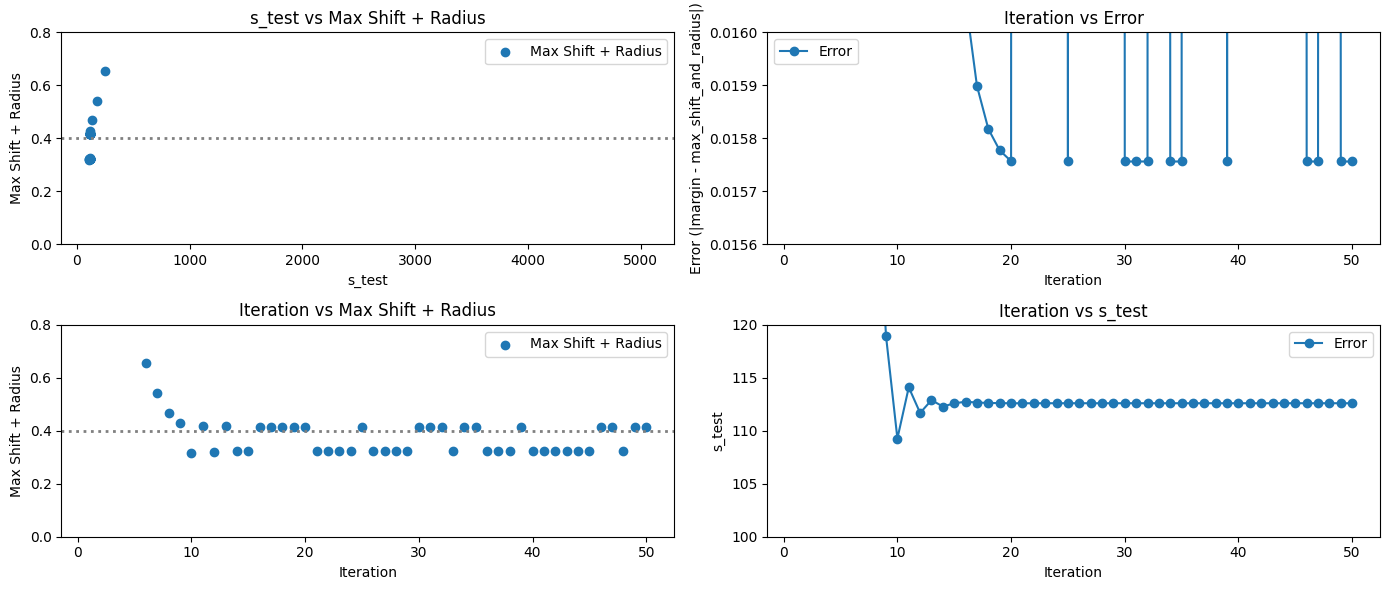

In [126]:
import pandas as pd

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# Panel 1: s_test vs max_shift_and_radius
axes[0, 0].scatter(history_df['s_test'], history_df['max_shift_and_radius'], label='Max Shift + Radius')
axes[0, 0].axhline(y=margin, color='gray', linestyle=':', linewidth=2)
axes[0, 0].set_ylim(0, 2 * margin)
axes[0, 0].set_xlabel('s_test')
axes[0, 0].set_ylabel('Max Shift + Radius')
axes[0, 0].set_title('s_test vs Max Shift + Radius')
axes[0, 0].legend()

# Panel 1: iteration vs max_shift_and_radius
axes[1, 0].scatter(history_df['iteration'], history_df['max_shift_and_radius'], label='Max Shift + Radius')
axes[1, 0].axhline(y=margin, color='gray', linestyle=':', linewidth=2)
axes[1, 0].set_ylim(0, 2 * margin)
axes[1,0].set_xlabel('Iteration')
axes[1,0].set_ylabel('Max Shift + Radius')
axes[1,0].set_title('Iteration vs Max Shift + Radius')
axes[1,0].legend()

# Panel 2: iteration vs error
axes[0, 1].plot(history_df['iteration'], abs(history_df['max_shift_and_radius'] - margin), marker='o', label='Error')
axes[0, 1].axhline(y=0, color='gray', linestyle=':', linewidth=2)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylim(0.0156, 0.016)
axes[0, 1].set_ylabel('Error (|margin - max_shift_and_radius|)')
axes[0, 1].set_title('Iteration vs Error')
axes[0, 1].legend()

# Panel 2: iteration vs error
axes[1, 1].plot(history_df['iteration'], abs(history_df['s_test'] - margin), marker='o', label='Error')
axes[1, 1].axhline(y=0, color='gray', linestyle=':', linewidth=2)
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('s_test')
axes[1, 1].set_title('Iteration vs s_test')
axes[1, 1].legend()
axes[1, 1].set_ylim(100, 120)
plt.tight_layout()
plt.show()